# Introduction

# Albotherm AXF — Exploratory Data Analysis
### Pipeline Step 3 of 4: Clean → Merge → **EDA** → Model






---

This notebook explores `axf_merged.csv` — the merged analysis dataset
produced in `albotherm_02_merge.ipynb`. It contains **770 rows** across
**628 unique AXF production runs**, with durability outcomes joined
from QC testing.

The goal here is not just description — it is **business-driven
investigation**. Every section is framed around a real question that
could change a formulation decision, a process setting, or a testing
priority.

---

### Dataset Summary

| | |
|---|---|
| Rows | 770 |
| Unique AXF runs | 612 |
| Columns | 45 |
| Runs with durability result | 619 (80%) |
| Runs without result yet | 151 (20%) |
| Unique UV formulations | 35 |
| Unique core formulations | 15 |

---

### Questions this notebook addresses

1. What does a passing durability score look like and where is the threshold?
2. Which UV formulation gives the most consistent passes?
3. Which formulation family performs best — and why?
4. Why does AUF110 — 36% of all runs — produce such inconsistent results?
5. Which process parameters are associated with better durability and stability?
6. Are the 151 untested runs randomly distributed or systematically different?
7. What is the operating process window for stable, passing capsules?
8. Which formulation should Albotherm prioritize going forward?

> Focus areas: UV formulation pass rate, drift from 24h to 48h,
> process parameter control, and operating window definition.

---

### Notebook Structure

| Section | Title | What it does | Key output |
|---|---|---|---|
| **1** | Data overview | What the dataset contains, how it is structured | Column definitions, data quality |
| **2** | Formulation overview | Which formulations exist, how many runs each has | Run count by formulation |
| **3** | Pass rate analysis | Which formulations pass the 24h durability test | Pass rates ranked by formulation |
| **4** | Drift analysis | Which formulations stay stable from 24h to 48h | Drift scores by formulation |
| **5** | Formulation family grouping | Grouping formulations by shared chemistry | Flexible family identified |
| **6** | Family level performance | Comparing performance across formulation families | Best-performing family identified |
| **7** | Process parameter analysis | Why performance varies within formulations | **Main finding of the notebook** |
| **7a** | AUF110 variance | Why AUF110 results are inconsistent | Process — not recipe — is the driver |
| **7b** | Process parameter correlation | Which settings drive 24h score and drift | Flow Rate Ratio is the key variable |
| **7c** | Operating window | What settings produce stable passing capsules | **Target process window defined** |
| **7d** | Final recommendation | What Albotherm should do | Flexible family + process standardization |
| **8** | Executive summary | The whole story in plain language | Start here if reading for the first time |
| **9** | Hypothesis |  what to do next | Hypothesis, Modelling roadmap |

---

### Recommended reading order

**If you are reading for the first time:**
-- Start with **Section 8** (Executive Summary)
-- Then **Section 7d** (Final Recommendation)
-- Then **Section 9** (Hypothesis, Optimisation and Modelling Direction)

**If you only want the answer:**
-- Go directly to **Section 8**

---

## 1. Loading merged dataset

In [ ]:
# Loading merged dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

axf_merged = pd.read_csv('../data/processed/axf_merged.csv')

print(f"Loaded: {axf_merged.shape[0]} rows × {axf_merged.shape[1]} columns")
print(f"Unique AXF runs : {axf_merged['batch_key'].nunique()}")
print(f"Columns         : {list(axf_merged.columns)}")


# We Load the formulation tables (the join on demand tables from notebook 02)
uv_comp   = pd.read_csv('../data/processed/uv_cleaned.csv')
core_comp = pd.read_csv('../data/processed/core_cleaned.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: 770 rows × 45 columns
Unique AXF runs : 612
Columns         : ['AXF Number', 'Date of experiment', 'Aims & Hypothesis', 'core_batch_id', 'Core Formulation', 'Core Viscosity (cP)', 'Amount of Core Used (g)', 'uv_batch_id', 'UV formulation', 'UV viscosity (cP)', 'Amount of UV Used (g)', 'Emulsion viscosity (cP)', 'Emulsion Gear Pump used', 'Single Emulsion (SE) Number', 'Vessel Used', 'Impellor Used', 'Mass of emulsion used / g', 'Impellor Speed (rpm)', 'Core Loading (%)', 'outer_batch_id', 'Outer viscosity (cP)', 'Outer Gear Pump Used', 'Dispersed Flow Rate (mL/min)', 'Continuous Flow Rate (mL/min)', 'Flow Rate Ratio', 'Cure Rig Used', 'Membrane Used (µm)', 'Insert used (mm)', 'Length of curing tubing (m)', 'Temperature of Outer Phase at end of experiment / C', 'UV Power (J s-1)', 'Curing Energy (kJ g-1)', 'batch_key', 'Batch number', 'Date durability 

## 2. Target Variable — Durability Outcome

The primary outcome is `% dry after 24h in humidity` — the percentage of
capsules that remain intact after 24 hours in a humidity chamber. A lower
score means better durability.

`QC Pass/Fail?` records the definitive binary judgement made by the QC team.
Per Albotherm's QC Lead:

> *"We first assess the ‘air dryness’ of a sample, which involves whether air has infiltrated our product. We do this after 24hrs and give the sample a ‘% air dry score’. We colour code the results accordingly where any batch of capsules that scores below 35% is coloured green, anything with a score of 36-70% is amber and any batch that is more than 71% is red. Caps that are ‘red’ or ‘amber’ are automatically failed.*
> — Isabelle, QC Lead, Albotherm

Threshold confirmed at **35%** — scores at or below 35% pass air dryness.
Scores above 35% are considered a fail.

This section covers two analyses:
- **2a** — 24h durability score distribution and pass/fail breakdown
- **2b** — 24h → 48h drift: does the score change meaningfully over time?

### 2a. 24h Durability — Primary Metric

24h Durability Summary
  Runs with result : 619 / 770
  Untested (NaN)   : 151
  Mean             : 49.2%
  Median           : 40.0%
  Std              : 30.5%
  Min / Max        : 2.0% / 100.0%

QC Pass/Fail breakdown:
QC Pass/Fail?
NaN     670
Fail     83
Pass     17


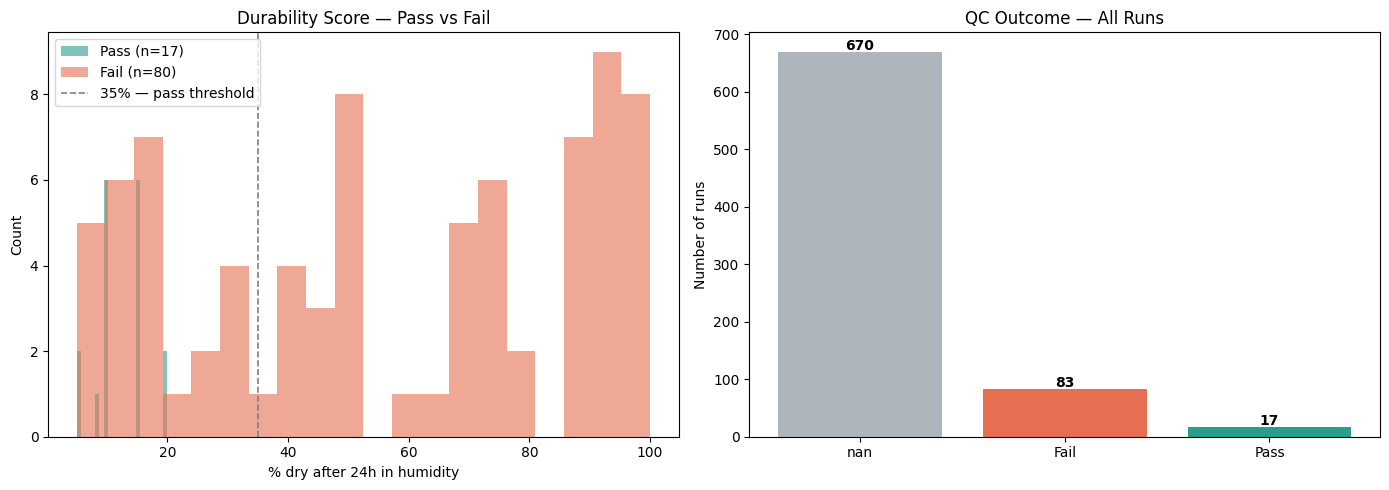

Saved: target_distribution.png


In [ ]:
t24    = '% dry after 24h in humidity'
tested = axf_merged[t24].dropna()

print("24h Durability Summary")
print(f"  Runs with result : {len(tested)} / {len(axf_merged)}")
print(f"  Untested (NaN)   : {axf_merged[t24].isna().sum()}")
print(f"  Mean             : {tested.mean():.1f}%")
print(f"  Median           : {tested.median():.1f}%")
print(f"  Std              : {tested.std():.1f}%")
print(f"  Min / Max        : {tested.min():.1f}% / {tested.max():.1f}%")
print(f"\nQC Pass/Fail breakdown:")
print(axf_merged['QC Pass/Fail?'].value_counts(dropna=False).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution — Pass vs Fail
for label, colour in [('Pass', '#2a9d8f'), ('Fail', '#e76f51')]:
    subset = axf_merged[axf_merged['QC Pass/Fail?'] == label][t24].dropna()
    axes[0].hist(subset, bins=20, alpha=0.6, color=colour,
                 label=f'{label} (n={len(subset)})')

axes[0].axvline(35, color='grey', linestyle='--', linewidth=1.2,
                label='35% — pass threshold')
axes[0].set_xlabel('% dry after 24h in humidity')
axes[0].set_ylabel('Count')
axes[0].set_title('Durability Score — Pass vs Fail')
axes[0].legend()

# Pass / Fail / Untested bar
pf_counts = axf_merged['QC Pass/Fail?'].value_counts(dropna=False)
colours   = ['#2a9d8f' if x == 'Pass' else '#e76f51' if x == 'Fail'
             else '#adb5bd' for x in pf_counts.index]
axes[1].bar(pf_counts.index.astype(str), pf_counts.values, color=colours)
axes[1].set_title('QC Outcome — All Runs')
axes[1].set_ylabel('Number of runs')
for i, v in enumerate(pf_counts.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()
print("Saved: target_distribution.png")

### Decision: Target Variable

`QC Pass/Fail?` is excluded as a modelling target. The QC judgement
incorporates polymer dry state and visual criteria for which no
corresponding data exists in this dataset. With 670 of 770 runs
unlabelled (87%), it cannot serve as a reliable target.

The modelling target is **`% dry after 24h in humidity`** — a
continuous, directly measured score available for 619 runs.

A score ≤ 35% corresponds to passing air dryness per the confirmed QC threshold.

### 2b. 24h - 48h % dry — Investigation

567 runs have a 48h result. 497 have both timepoints. The two scores
correlate strongly (r = 0.893), confirming they measure the same underlying durability.

This analysis is **not** a second target — it is an investigation. We ask:
does the score change meaningfully between 24h and 48h, and if so,
which formulations are responsible? Drift here is defined as:

    drift = (% dry at 48h) − (% dry at 24h)

A positive drift means the capsule deteriorated further after 24h.
A negative drift means it recovered (less common, worth flagging).

Drift Summary (48h − 24h)
  Runs with both timepoints : 497
  Mean drift                : 8.08%
  Median drift              : 5.00%
  Worsened  (drift >  +5%)  : 192
  Improved  (drift <  -5%)  : 24
  Stable    (|drift| ≤  5%) : 281


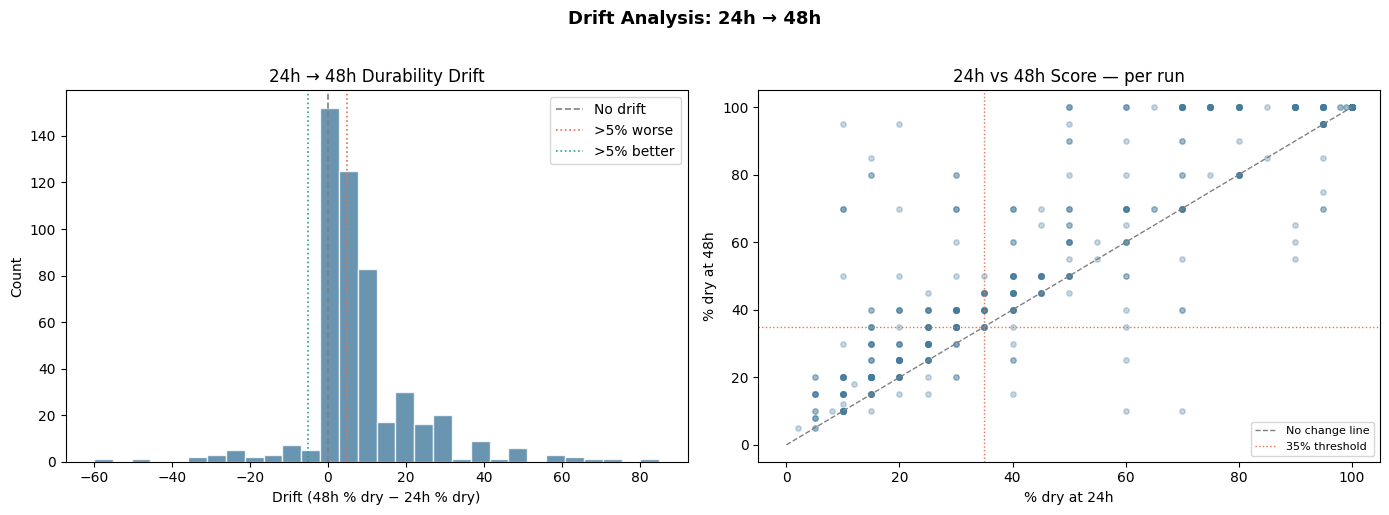

Saved: drift_analysis.png


In [ ]:
t24 = '% dry after 24h in humidity'
t48 = '% dry after 2 days in humidity chamber'

both = axf_merged[[t24, t48, 'UV formulation',
                   'batch_key']].dropna(subset=[t24, t48]).copy()
both['drift'] = both[t48] - both[t24]

print("Drift Summary (48h − 24h)")
print(f"  Runs with both timepoints : {len(both)}")
print(f"  Mean drift                : {both['drift'].mean():.2f}%")
print(f"  Median drift              : {both['drift'].median():.2f}%")
print(f"  Worsened  (drift >  +5%)  : {(both['drift'] >  5).sum()}")
print(f"  Improved  (drift <  -5%)  : {(both['drift'] < -5).sum()}")
print(f"  Stable    (|drift| ≤  5%) : {(both['drift'].abs() <= 5).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — drift distribution
axes[0].hist(both['drift'], bins=30, color='#457b9d', alpha=0.8, edgecolor='white')
axes[0].axvline(0,  color='grey',    linestyle='--', linewidth=1.2, label='No drift')
axes[0].axvline(5,  color='#e76f51', linestyle=':',  linewidth=1.2, label='>5% worse')
axes[0].axvline(-5, color='#2a9d8f', linestyle=':',  linewidth=1.2, label='>5% better')
axes[0].set_xlabel('Drift (48h % dry − 24h % dry)')
axes[0].set_ylabel('Count')
axes[0].set_title('24h → 48h Durability Drift')
axes[0].legend()

# Right — 24h vs 48h scatter with threshold lines
axes[1].scatter(both[t24], both[t48], alpha=0.3, color='#457b9d', s=15)
axes[1].plot([0, 100], [0, 100], 'grey', linestyle='--', linewidth=1, label='No change line')
axes[1].axvline(35, color='#e76f51', linestyle=':', linewidth=1, label='35% threshold')
axes[1].axhline(35, color='#e76f51', linestyle=':', linewidth=1)
axes[1].set_xlabel('% dry at 24h')
axes[1].set_ylabel('% dry at 48h')
axes[1].set_title('24h vs 48h Score — per run')
axes[1].legend(fontsize=8)

plt.suptitle('Drift Analysis: 24h → 48h', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('drift_analysis.png', dpi=150)
plt.show()
print("Saved: drift_analysis.png")

### Decision: Drift

The 24h score is confirmed as the primary modelling target.

The majority of runs are stable between 24h and 48h (281 of 497, 56.5%).
However, 192 runs (38.6%) showed meaningful deterioration beyond 24h
(drift > +5%), with a mean drift of +8.1% across all paired runs.

The direction of drift is almost always worsening — only 24 runs
improved. This means **24h is a stable reliable indicator**:
a run that passes at 24h is very likely still passing at 48h.

The 48h column is retained in the dataset as a investigative variable.
Drift by UV formulation will be explored in Section 5 (feature analysis).

## 3. Feature Overview

Before modelling, we look at what input variables are available.
Features come from four sources:

- **UV formulation** — coating chemistry parameters (UV curing agent,
  concentrations, ratios)
- **Mix parameters** — blending conditions (speed, time, temperature)
- **Core parameters** — capsule core composition
- **Batch data** — run identifiers, dates, operator flags

This section counts available features, flags missingness, and identifies
which columns are continuous vs categorical.

Total features available : 41
Continuous               : 15
Categorical              : 26

High missingness (>50%)  : 8 columns
Low missingness  (<10%)  : 30 columns

Top 15 highest missingness:
                                             column        type  non_null  null_pct
                             Date durability set up categorical        58      92.5
               Do caps turn off and/or on? at 24hrs categorical        81      89.5
                   Do caps look on or off at 24hrs? categorical        92      88.1
                                      On/Off at RT? categorical       123      84.0
                                           QC Notes categorical       160      79.2
                          Bulk coating compability? categorical       190      75.3
                             Coating compatibility? categorical       191      75.2
Temperature of Outer Phase at end of experiment / C categorical       261      66.1
                                manufacturing not

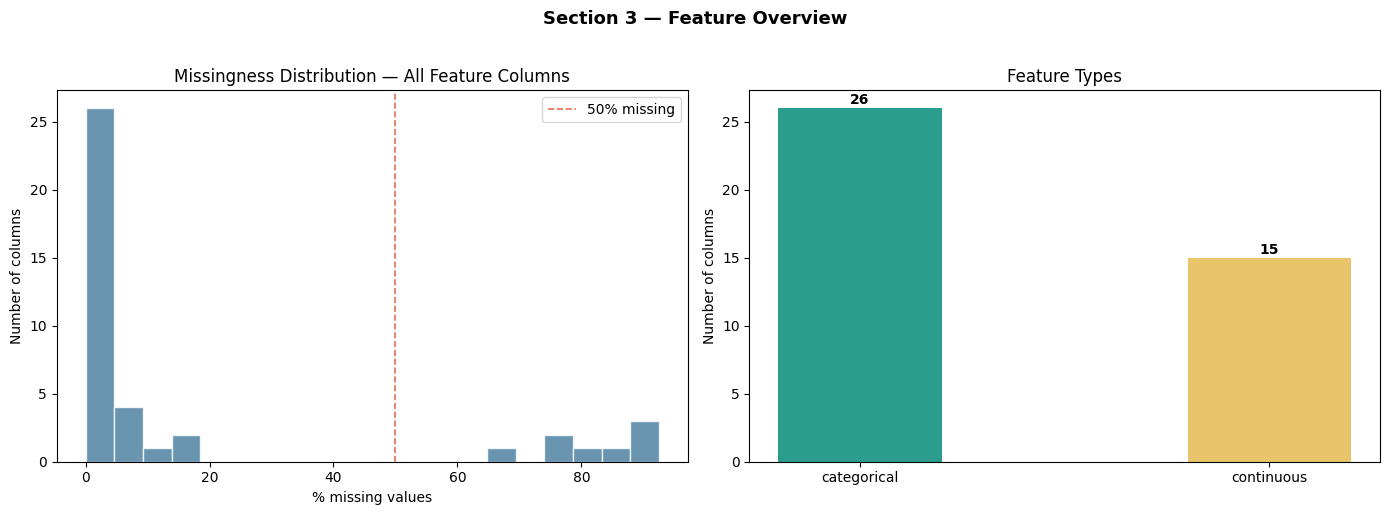

Saved: feature_overview.png


In [ ]:
t24 = '% dry after 24h in humidity'
t48 = '% dry after 2 days in humidity chamber'

# Columns that are NOT features
exclude = [t24, t48, 'QC Pass/Fail?', 'batch_key']

feature_cols = [c for c in axf_merged.columns if c not in exclude]

# Build summary table
summary = pd.DataFrame({
    'column'    : feature_cols,
    'dtype'     : [axf_merged[c].dtype for c in feature_cols],
    'non_null'  : [axf_merged[c].notna().sum() for c in feature_cols],
    'null_count': [axf_merged[c].isna().sum() for c in feature_cols],
    'null_pct'  : [(axf_merged[c].isna().mean() * 100).round(1)
                   for c in feature_cols],
    'n_unique'  : [axf_merged[c].nunique() for c in feature_cols],
})

summary['type'] = summary.apply(
    lambda r: 'categorical' if r['dtype'] == 'object' or r['n_unique'] < 10
              else 'continuous', axis=1)

summary = summary.sort_values('null_pct', ascending=False)

print(f"Total features available : {len(feature_cols)}")
print(f"Continuous               : {(summary['type'] == 'continuous').sum()}")
print(f"Categorical              : {(summary['type'] == 'categorical').sum()}")
print(f"\nHigh missingness (>50%)  : {(summary['null_pct'] > 50).sum()} columns")
print(f"Low missingness  (<10%)  : {(summary['null_pct'] < 10).sum()} columns")
print(f"\nTop 15 highest missingness:")
print(summary[['column','type','non_null','null_pct']]
      .head(15).to_string(index=False))

# Chart — missingness by column
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — missingness distribution
axes[0].hist(summary['null_pct'], bins=20,
             color='#457b9d', alpha=0.8, edgecolor='white')
axes[0].axvline(50, color='#e76f51', linestyle='--',
                linewidth=1.2, label='50% missing')
axes[0].set_xlabel('% missing values')
axes[0].set_ylabel('Number of columns')
axes[0].set_title('Missingness Distribution — All Feature Columns')
axes[0].legend()

# Right — feature type breakdown
type_counts = summary['type'].value_counts()
colours = ['#2a9d8f', '#e9c46a']
axes[1].bar(type_counts.index, type_counts.values,
            color=colours, width=0.4)
axes[1].set_title('Feature Types')
axes[1].set_ylabel('Number of columns')
for i, v in enumerate(type_counts.values):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.suptitle('Section 3 — Feature Overview',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_overview.png', dpi=150)
plt.show()
print("Saved: feature_overview.png")

### Decision: Feature Selection — Missingness

8 columns with >50% missing values are excluded from modelling.
All 8 are post-hoc observations or admin fields recorded alongside
the durability test not formulation inputs. Including them would
introduce data leakage (they describe the outcome, not the process).

Columns dropped:
- Date durability set up (92.5% missing)
- Do caps turn off and/or on? at 24hrs (89.5% missing)
- Do caps look on or off at 24hrs? (88.1% missing)
- On/Off at RT? (84.0% missing)
- QC Notes (79.2% missing)
- Bulk coating compatibility? (75.3% missing)
- Coating compatibility? (75.2% missing)
- Temperature of Outer Phase at end of experiment (66.1% missing)

Remaining: **33 features** across 15 continuous and 18 categorical columns.
The 15 continuous features will be the primary candidates for modelling.

## 4. Working Dataset

Before exploratory analysis, we prepare a clean working dataframe by:

1. Dropping the 8 columns with >50% missing — all are post observations,
   not formulation inputs
2. Dropping the 151 rows with no 24h durability score — these cannot
   contribute to any durability analysis
3. Adding a convenience column `passed` (True if score ≤ 35%)



In [ ]:
t24 = '% dry after 24h in humidity'

drop_cols = [
    'Date durability set up',
    'Do caps turn off and/or on? at 24hrs',
    'Do caps look on or off at 24hrs?',
    'On/Off at RT?',
    'QC Notes',
    'Bulk coating compability?',
    'Coating compatibility?',
    'Temperature of Outer Phase at end of experiment / C',
]

# Drop high-missingness columns and rows with no 24h score
axf_eda = (axf_merged
           .drop(columns=drop_cols, errors='ignore')
           .dropna(subset=[t24])
           .copy())

# Convenience pass/fail flag based on confirmed 35% threshold
axf_eda['passed'] = axf_eda[t24] <= 35

print("Working dataset ready")
print(f"  Rows    : {len(axf_eda)}")
print(f"  Columns : {len(axf_eda.columns)}")
print(f"  Pass    : {axf_eda['passed'].sum()} ({axf_eda['passed'].mean():.1%})")
print(f"  Fail    : {(~axf_eda['passed']).sum()} ({(~axf_eda['passed']).mean():.1%})")

axf_eda.to_csv('axf_eda.csv', index=False)
print("Saved: axf_eda.csv")

Working dataset ready
  Rows    : 619
  Columns : 38
  Pass    : 267 (43.1%)
  Fail    : 352 (56.9%)
Saved: axf_eda.csv


## 5. Exploratory Data Analysis

This section explores relationships between formulation/process variables
and the 24h durability score. It is structured in two parts:

**Categorical variables:** which formulation types are explored and why
**Continuous variables:** how process parameters relate to outcome
**Deep dives:** UV formulation, Core formulation, Equipment effects

### 5a. Continuous Features — Overview

15 continuous features are available. The four with best coverage and
most direct process relevance are explored here:

- **Curing Energy (kJ g⁻¹)** — total UV energy applied during curing
- **UV Power (J s⁻¹)** — rate of UV energy delivery
- **Emulsion Viscosity (cP)** — thickness of the emulsion before coating
- **Mass of emulsion used (g)** — quantity applied per run

Each scatter plot shows individual runs coloured by pass/fail.
The 35% threshold is shown for reference.

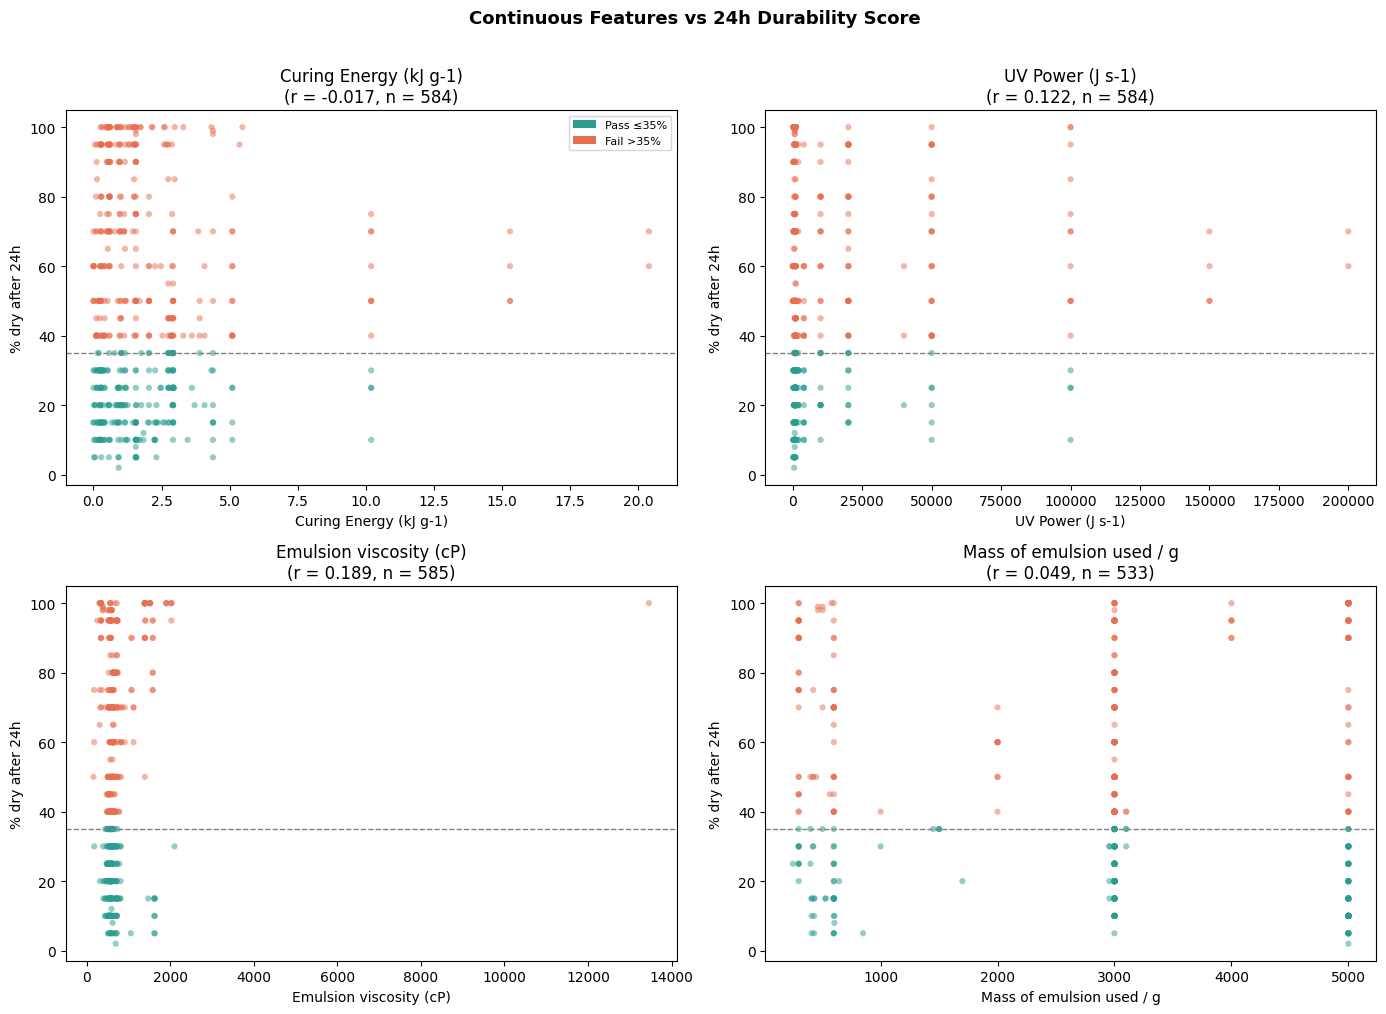

Correlations with 24h score:
  Curing Energy (kJ g-1)              r = -0.017  (n=584)
  UV Power (J s-1)                    r = 0.122  (n=584)
  Emulsion viscosity (cP)             r = 0.189  (n=585)
  Mass of emulsion used / g           r = 0.049  (n=533)


In [ ]:
t24 = '% dry after 24h in humidity'

continuous_features = [
    'Curing Energy (kJ g-1)',
    'UV Power (J s-1)',
    'Emulsion viscosity (cP)',
    'Mass of emulsion used / g',
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(continuous_features):
    subset = axf_eda[[feat, t24, 'passed']].dropna()
    c = subset['passed'].map({True: '#2a9d8f', False: '#e76f51'})
    corr = subset[feat].corr(subset[t24])

    axes[i].scatter(subset[feat], subset[t24],
                    c=c, alpha=0.5, s=20, edgecolors='none')
    axes[i].axhline(35, color='grey', linestyle='--',
                    linewidth=1, label='35% threshold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('% dry after 24h')
    axes[i].set_title(f'{feat}\n(r = {corr:.3f}, n = {len(subset)})')

    if i == 0:
        from matplotlib.patches import Patch
        axes[i].legend(handles=[
            Patch(facecolor='#2a9d8f', label='Pass ≤35%'),
            Patch(facecolor='#e76f51', label='Fail >35%')
        ], fontsize=8)

plt.suptitle('Continuous Features vs 24h Durability Score',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('continuous_features.png', dpi=150)
plt.show()

print("Correlations with 24h score:")
for feat in continuous_features:
    subset = axf_eda[[feat, t24]].dropna()
    corr = subset[feat].corr(subset[t24])
    print(f"  {feat:<35} r = {corr:.3f}  (n={len(subset)})")

#### Findings: Continuous Features

None of the four continuous parameters show strong linear correlation
with the 24h durability score (all |r| < 0.20):

| Feature | r | Variance explained (r²) |
|---|---|---|
| Curing Energy (kJ g⁻¹) | −0.017 | 0.03% |
| UV Power (J s⁻¹) | +0.122 | 1.5% |
| Emulsion Viscosity (cP) | +0.189 | 3.6% |
| Mass of emulsion used (g) | +0.049 | 0.2% |

Together these features leave over 94% of durability variation unexplained.
Durability is not driven by individual process settings in isolation.
The **formulation type** is the more likely primary driver, explored next.

### 5b. Correlation Heatmap — Continuous Features

A heatmap of pairwise correlations between all continuous features and
the durability score. This reveals whether any features are inter related
(multicollinearity) and confirms which have the strongest link to outcome.

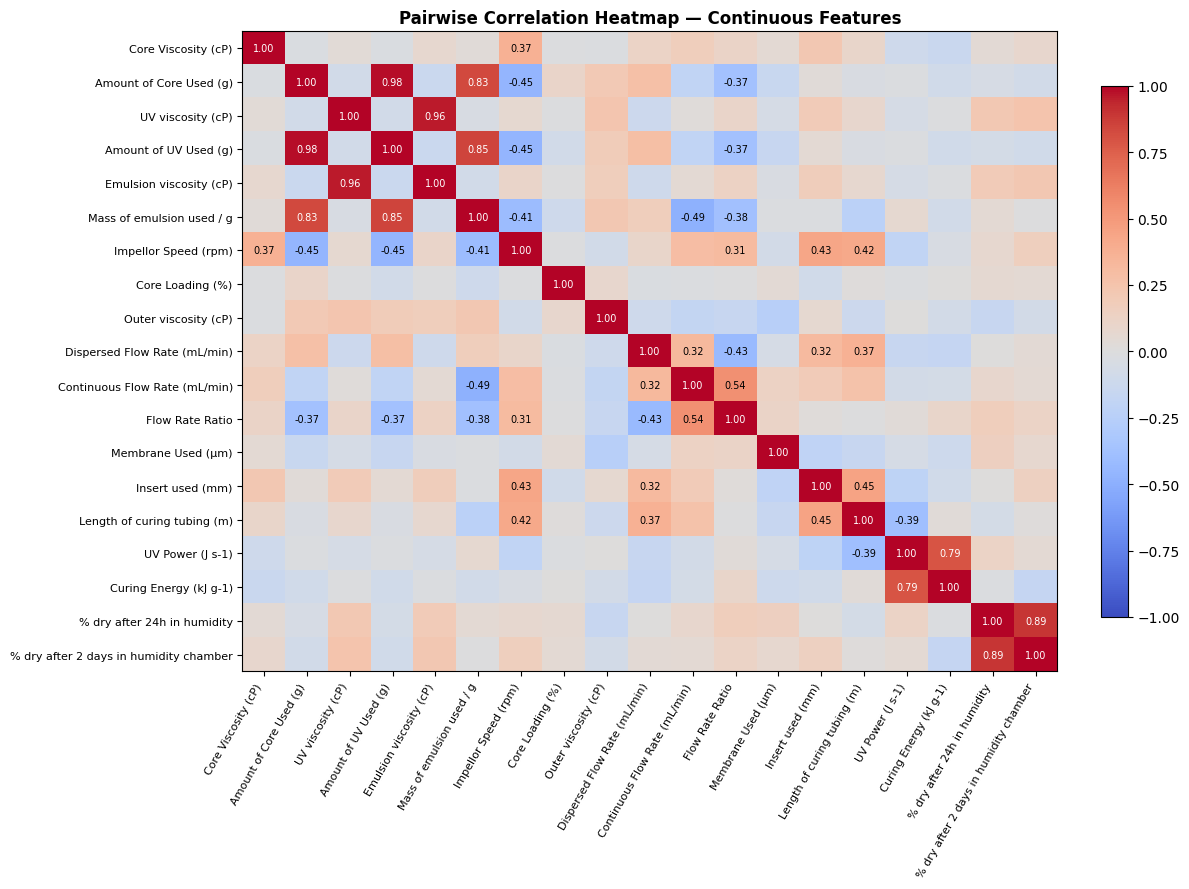

Saved: correlation_heatmap.png


In [ ]:
t24 = '% dry after 24h in humidity'

num_cols = axf_eda.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'passed']

corr_matrix = axf_eda[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.03)

ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=60, ha='right', fontsize=8)
ax.set_yticklabels(num_cols, fontsize=8)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.3:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if abs(val) > 0.6 else 'black')

ax.set_title('Pairwise Correlation Heatmap — Continuous Features',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("Saved: correlation_heatmap.png")

#### Findings: Correlation Heatmap

Three clusters of inter correlated continuous features are visible:

**1. Volume / mass cluster** — `Amount of Core Used`, `Amount of UV Used`,
`UV viscosity`, `Emulsion viscosity`, and `Mass of emulsion used` are
strongly inter-correlated (r = 0.83–0.98). These move together because
they all scale with batch size. For future modelling, only one
representative from this group is needed to avoid multicollinearity.

**2. Flow rate cluster** — `Dispersed Flow Rate`, `Continuous Flow Rate`,
and `Flow Rate Ratio` are moderately correlated (r = 0.32–0.54),
reflecting that emulsification conditions are set together.

**3. UV curing cluster** — `UV Power` and `Curing Energy` are strongly
correlated (r = 0.79), as are `Insert used` and `Length of curing tubing`
(r = 0.45). Rig configuration drives both simultaneously.

**None of the continuous features show meaningful correlation with the
24h durability score** (all |r| < 0.15). This confirms the conclusion
from Section 5a — durability is driven by **formulation type**, not
individual process settings. The heatmap also confirms the 24h to 48h
correlation of r = 0.89 established in Section 2b.

### 5c. Categorical Features vs Durability Score

Not all categorical columns are suitable for analysis. We apply three
selection criteria — the same logic used for continuous features in 5b:

| Criterion | Rule | Reason |
|---|---|---|
| **Unique values** | 2–35 | Fewer than 2 = constant; more than 35 = acts as ID |
| **Coverage** | ≥ 80% filled | Too sparse to draw reliable conclusions |
| **Role** | Formulation or equipment input | Outcome columns and identifiers excluded |

This leaves six categorical features for exploration.

In [ ]:
# Derive candidates columns — same logic as the table in 5a
cat_cols = axf_eda.select_dtypes(include='object').columns.tolist()

exclude  = ['AXF Number', 'Date of experiment', 'Aims & Hypothesis',
            'core_batch_id', 'uv_batch_id', 'outer_batch_id',
            'batch_key', 'Batch number', 'manufacturing notes',
            'Single Emulsion (SE) Number', 'QC Pass/Fail?',
            'Outer Gear Pump Used']   # constant column

candidates = [c for c in cat_cols
              if c not in exclude
              and 2 <= axf_eda[c].nunique() <= 35
              and axf_eda[c].notna().mean() >= 0.80]

print("Categorical features selected for 3. analysis:")
for c in candidates:
    print(f"  {c:<30} unique={axf_eda[c].nunique():<5} "
          f"filled={axf_eda[c].notna().sum()}/619")

Categorical features selected for analysis:
  Core Formulation               unique=10    filled=619/619
  UV formulation                 unique=35    filled=619/619
  Emulsion Gear Pump used        unique=2     filled=619/619
  Vessel Used                    unique=2     filled=619/619
  Impellor Used                  unique=4     filled=619/619
  Cure Rig Used                  unique=8     filled=616/619


In [ ]:
t24 = '% dry after 24h in humidity'

candidates = {
    'UV formulation'         : (35, 619),
    'Core Formulation'       : (10, 619),
    'Cure Rig Used'          : (8,  616),
    'Impellor Used'          : (4,  619),
    'Vessel Used'            : (2,  619),
    'Emulsion Gear Pump used': (2,  619),
}

print(f"{'Feature':<28} {'Unique':>8} {'Coverage':>10} "
      f"{'Pass rate range':>20} {'Median range':>18} {'Selected':>10}")
print("-" * 100)

for col, (n_unique, n_filled) in candidates.items():
    grp = (axf_eda.groupby(col)
           .agg(pass_rate=('passed','mean'),
                median=(t24,'median'))
           .reset_index())
    pr_range = f"{grp['pass_rate'].min()*100:.0f}%–{grp['pass_rate'].max()*100:.0f}%"
    md_range = f"{grp['median'].min():.0f}%–{grp['median'].max():.0f}%"
    coverage = f"{n_filled}/619"
    print(f"  {col:<26} {n_unique:>8} {coverage:>10} "
          f"{pr_range:>20} {md_range:>18} {'Yes':>10}")

Feature                        Unique   Coverage      Pass rate range       Median range   Selected
----------------------------------------------------------------------------------------------------
  UV formulation                   35    619/619              0%–100%           12%–100%        Yes
  Core Formulation                 10    619/619               0%–80%            10%–95%        Yes
  Cure Rig Used                     8    616/619               0%–50%            32%–95%        Yes
  Impellor Used                     4    619/619               0%–44%            40%–75%        Yes
  Vessel Used                       2    619/619              38%–44%            40%–50%        Yes
  Emulsion Gear Pump used           2    619/619              33%–44%            40%–60%        Yes


#### Findings: Categorical Feature Selection

The pass rate range across groups reveals the impact of each variable:

- **UV Formulation** shows the widest range (0%–100%) — some chemistries
  consistently fail every run, others consistently pass. This is the
  dominant driver of durability
- **Core Formulation** also shows a wide range (0%–80%) — core composition
  is a secondary but meaningful driver
- **Cure Rig** and **Impellor** show moderate ranges — equipment
  introduces some variation but is not the primary driver
- **Vessel** and **Gear Pump** show negligible range (≤6 percentage
  points) — these variables have almost no effect on outcome and will
  not be explored further

following sections focus on UV Formulation, Core Formulation, and Cure Rig /
Impellor respectively — in order of impact.

### 5d. UV Formulation vs Durability Score

UV formulation showed the widest pass rate range (0%–100%) of all
categorical variables. This section examines all 35 UV chemistries in detail.

Two charts are shown together:
- **Box plot** — shows score distribution and spread per formulation,
  ranked by median score (lowest = best on the left). Run count (n) is
  shown on each label so the reader can judge reliability. Minitab
  recommends n ≥ 20 for a reliable box plot [Minitab, 2024] — Therefore, formulation groups below should be interpreted with caution
- **Pass rate bar chart** — This tells us, what % of runs passed
  per formulation. More robust for small groups than the box plot

Both charts use the same colour coding:
Green — pass rate ≥50% |  Amber — 30–50% | Red — <30%

UV Formulation — all groups ranked by median score (lower = better):
UV formulation   n  median       mean  pass_pct
        AUF075  10    12.5  11.000000     100.0
        AUF274   4    17.5  17.500000     100.0
        AUF285  43    20.0  23.837209      81.4
        AUF076  82    20.0  21.646341      84.1
        AUF302   8    20.0  20.625000     100.0
        AUF333   6    25.0  25.833333     100.0
        AUF197   4    32.5  28.750000      75.0
        AUF331   4    35.0  35.000000      75.0
        AUF110 213    40.0  46.159624      44.1
        AUF134   3    40.0  53.333333      33.3
        AUF069   1    45.0  45.000000       0.0
        AUF277   2    47.5  47.500000      50.0
        AUF092   1    50.0  50.000000       0.0
        AUF103  22    50.0  50.454545      18.2
        AUF275  59    50.0  55.847458      20.3
        AUF279  14    50.0  52.500000      21.4
        AUF090   2    52.5  52.500000      50.0
        AUF096   4    55.0  53.750000      25.0
        AUF194   4 

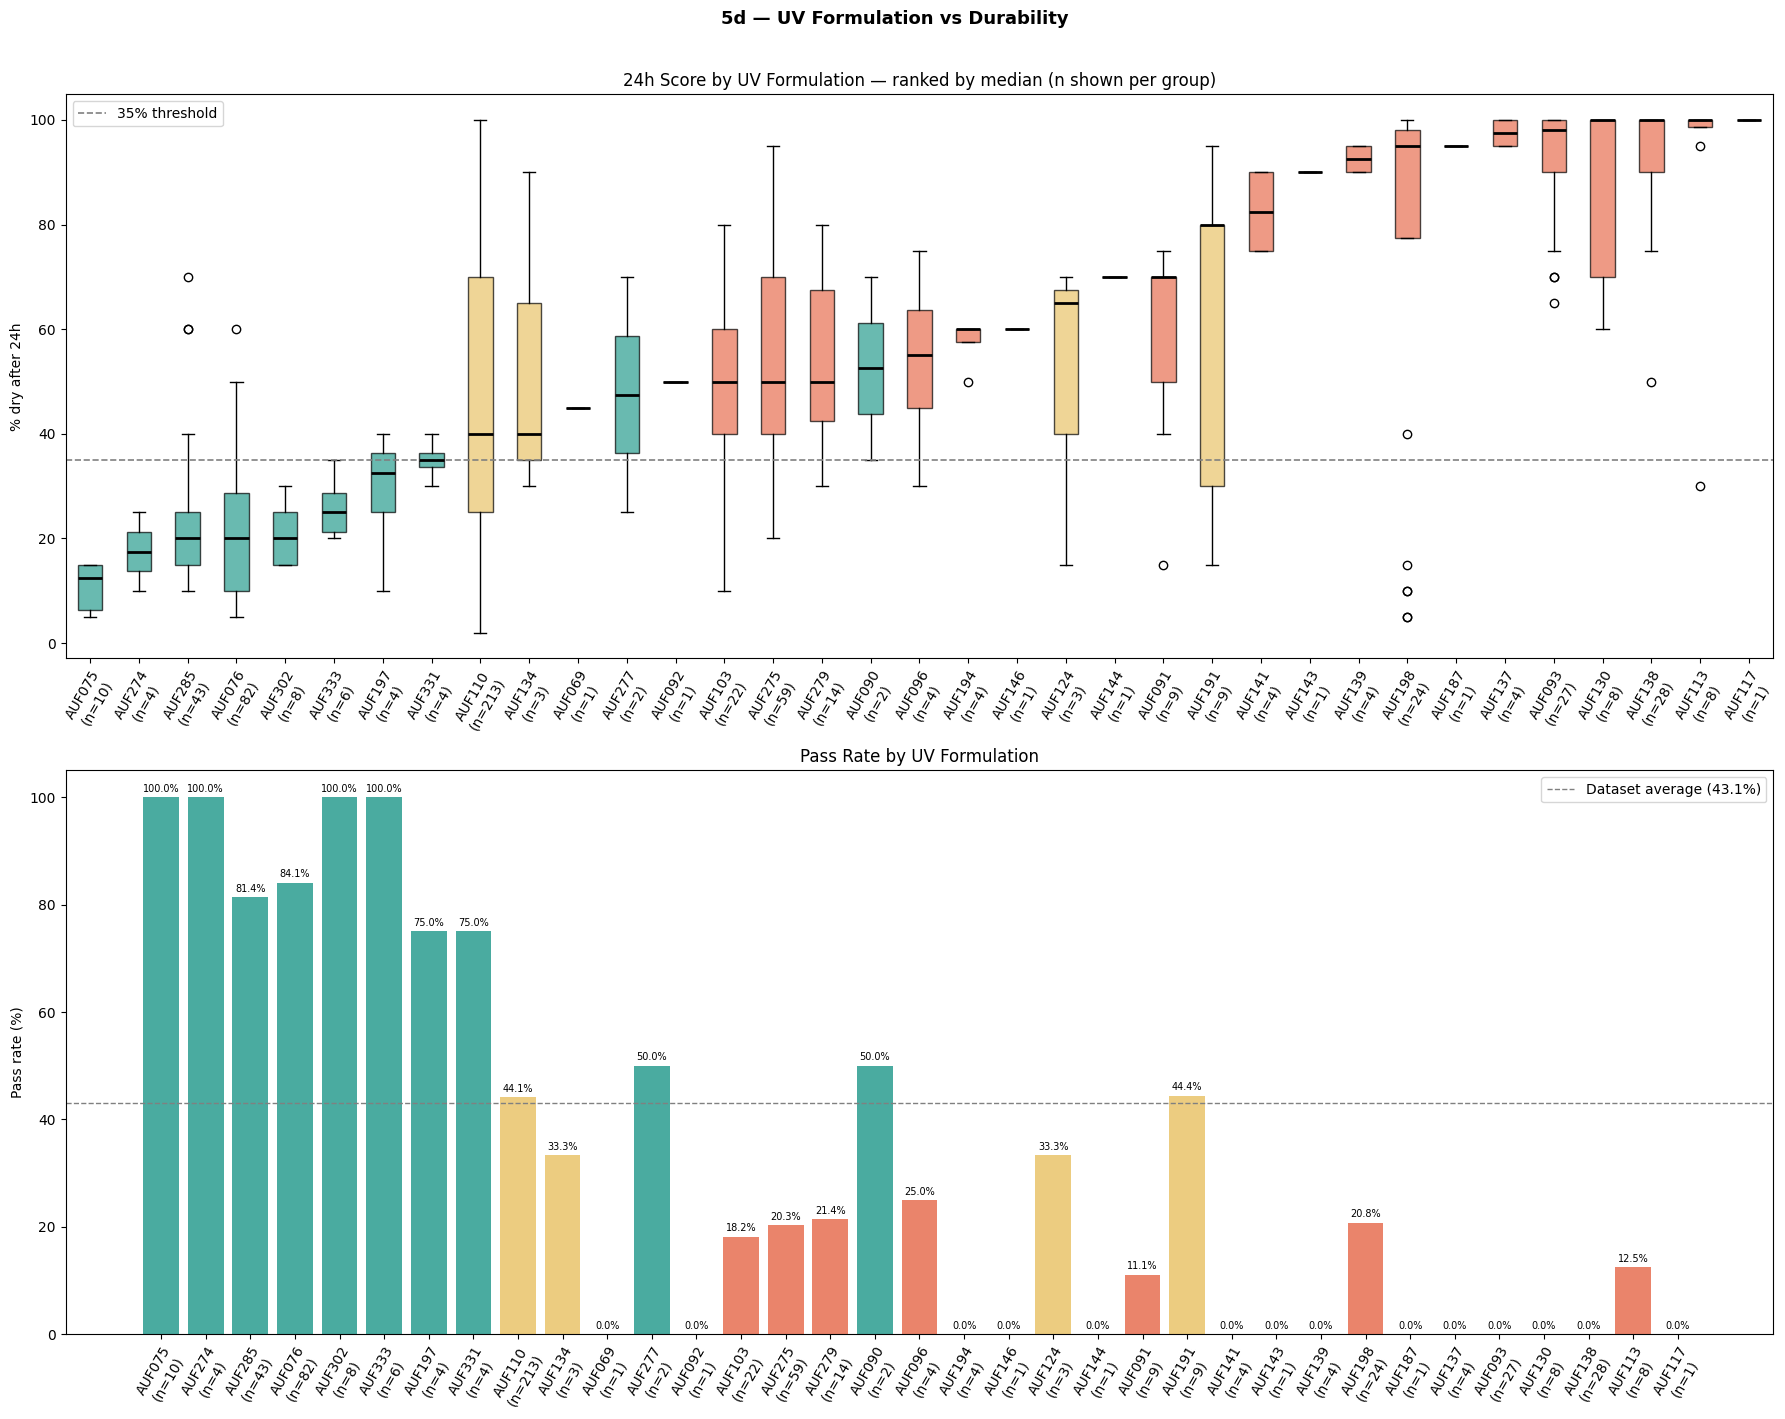

Saved: uv_formulation.png


In [ ]:
t24    = '% dry after 24h in humidity'
uv_col = 'UV formulation'

uv_summary = (axf_eda.groupby(uv_col)
              .agg(n=(t24, 'count'),
                   median=(t24, 'median'),
                   mean=(t24, 'mean'),
                   pass_rate=('passed', 'mean'))
              .reset_index()
              .sort_values('median'))
uv_summary['pass_pct'] = (uv_summary['pass_rate'] * 100).round(1)

print("UV Formulation — all groups ranked by median score (lower = better):")
print(uv_summary[[uv_col, 'n', 'median', 'mean', 'pass_pct']].to_string(index=False))

order          = uv_summary[uv_col].tolist()
order_labelled = [f"{f}\n(n={uv_summary[uv_summary[uv_col]==f]['n'].values[0]})"
                  for f in order]

fig, axes = plt.subplots(2, 1, figsize=(18, 14))

groups = [axf_eda[axf_eda[uv_col] == f][t24].dropna() for f in order]
bp = axes[0].boxplot(groups, tick_labels=order_labelled, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
colours_box = ['#2a9d8f' if r >= 0.5 else '#e9c46a' if r >= 0.3
               else '#e76f51' for r in uv_summary['pass_rate']]
for patch, c in zip(bp['boxes'], colours_box):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[0].axhline(35, color='grey', linestyle='--', linewidth=1.2,
                label='35% threshold')
axes[0].set_ylabel('% dry after 24h')
axes[0].set_title('24h Score by UV Formulation — ranked by median (n shown per group)')
axes[0].tick_params(axis='x', rotation=60)
axes[0].legend()

bar_colours = ['#2a9d8f' if r >= 0.5 else '#e9c46a' if r >= 0.3
               else '#e76f51' for r in uv_summary['pass_rate']]
bars = axes[1].bar(order_labelled, uv_summary['pass_pct'],
                   color=bar_colours, alpha=0.85)
axes[1].axhline(43.1, color='grey', linestyle='--', linewidth=1,
                label='Dataset average (43.1%)')
axes[1].set_ylabel('Pass rate (%)')
axes[1].set_title('Pass Rate by UV Formulation')
axes[1].tick_params(axis='x', rotation=60)
axes[1].legend()
for bar, v in zip(bars, uv_summary['pass_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + 1, f'{v}%', ha='center', fontsize=7)

plt.suptitle('5d — UV Formulation vs Durability',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('uv_formulation.png', dpi=150)
plt.show()
print("Saved: uv_formulation.png")

#### Findings: UV Formulation

A clear 3 tier structure emerges across 35 UV formulations:

**Tier 1 — Consistently good (pass rate ≥75%, median ≤35%):**
Six formulations achieve high pass rates. AUF076 (n=82, 84%) and
AUF285 (n=43, 81%) are the most statistically reliable performers —
large groups with consistently low 24h scores well below the 35%
threshold.

**Tier 2 — Inconsistent (pass rate 18–50%, median 35–55%):**
AUF110 is the most important formulation in the dataset — it accounts
for 213 of 619 runs (34%) yet achieves only a 44% pass rate. Its wide
interquartile range in the box plot confirms high run to run variability.
AUF103 (n=22, 18%) and AUF279 (n=14, 21%) also sit in this tier.

**Tier 3 — Consistently poor (pass rate 0–20%, median ≥60%):**
AUF275 (n=59, 20%), AUF138 (n=28, 0%), AUF093 (n=27, 0%), and
AUF198 (n=24, 21%) are large groups with near-zero pass rates.
These formulations consistently fail and account for a substantial
portion of failed runs in the dataset.

UV formulation is confirmed as the primary driver of durability outcome.

### 5e. Core Formulation vs Durability Score

Core formulation showed the second widest pass rate range (0%–80%)
in the categorical overview. 10 distinct core compositions are tested
across all 619 runs. As with 5d, run count (n) is shown on each label.

Core Formulation — ranked by median score (lower = better):
Core Formulation   n  median      mean  pass_pct
      RAD-C-0004   5    10.0 18.000000      80.0
      RAD-C-0034   4    25.0 38.750000      75.0
      RAD-C-0009   6    32.5 40.000000      50.0
      RAD-C-0003   1    40.0 40.000000       0.0
      RAD-C-0001 508    40.0 46.212598      46.5
      RAD-C-0015   1    45.0 45.000000       0.0
      RAD-C-0008  11    50.0 56.818182      36.4
      RAD-C-0002  60    65.0 62.083333      26.7
      RAD-C-0006   3    95.0 88.333333       0.0
      RAD-C-0007  20    95.0 89.950000       5.0


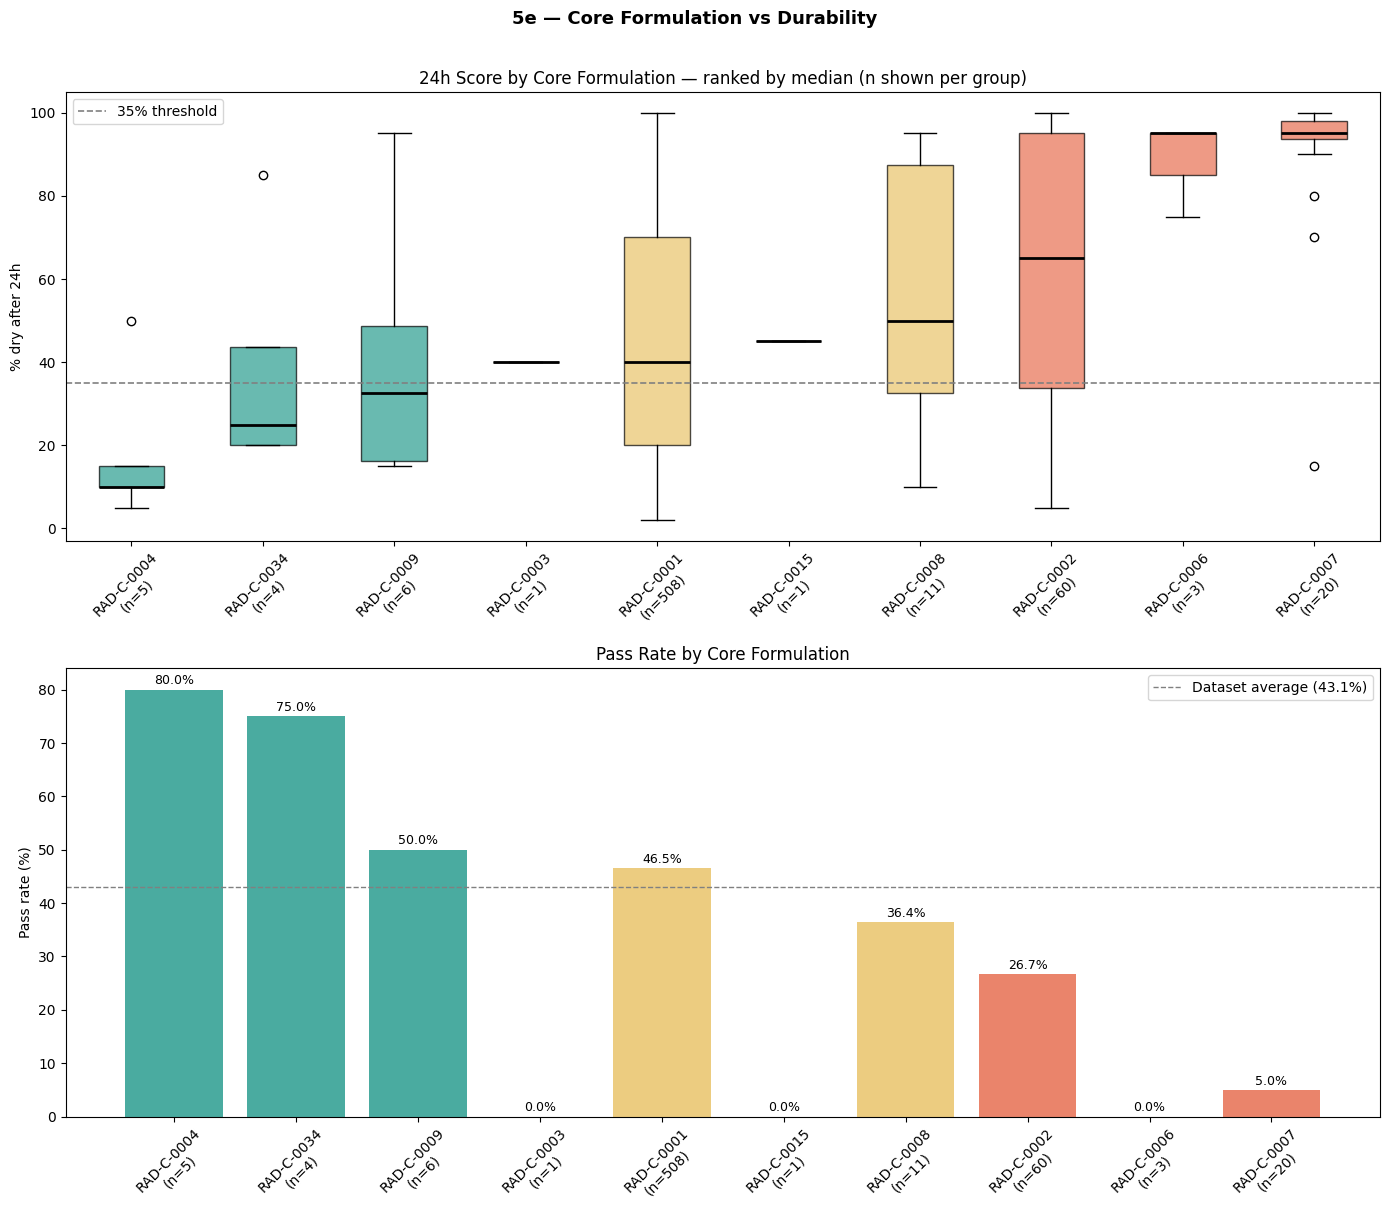

Saved: core_formulation.png


In [ ]:
t24      = '% dry after 24h in humidity'
core_col = 'Core Formulation'

core_summary = (axf_eda.groupby(core_col)
                .agg(n=(t24, 'count'),
                     median=(t24, 'median'),
                     mean=(t24, 'mean'),
                     pass_rate=('passed', 'mean'))
                .reset_index()
                .sort_values('median'))
core_summary['pass_pct'] = (core_summary['pass_rate'] * 100).round(1)

print("Core Formulation — ranked by median score (lower = better):")
print(core_summary[[core_col, 'n', 'median', 'mean', 'pass_pct']].to_string(index=False))

order          = core_summary[core_col].tolist()
order_labelled = [f"{f}\n(n={core_summary[core_summary[core_col]==f]['n'].values[0]})"
                  for f in order]

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

groups = [axf_eda[axf_eda[core_col] == f][t24].dropna() for f in order]
bp = axes[0].boxplot(groups, tick_labels=order_labelled, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
colours_box = ['#2a9d8f' if r >= 0.5 else '#e9c46a' if r >= 0.3
               else '#e76f51' for r in core_summary['pass_rate']]
for patch, c in zip(bp['boxes'], colours_box):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[0].axhline(35, color='grey', linestyle='--', linewidth=1.2,
                label='35% threshold')
axes[0].set_ylabel('% dry after 24h')
axes[0].set_title('24h Score by Core Formulation — ranked by median (n shown per group)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

bar_colours = ['#2a9d8f' if r >= 0.5 else '#e9c46a' if r >= 0.3
               else '#e76f51' for r in core_summary['pass_rate']]
bars = axes[1].bar(order_labelled, core_summary['pass_pct'],
                   color=bar_colours, alpha=0.85)
axes[1].axhline(43.1, color='grey', linestyle='--', linewidth=1,
                label='Dataset average (43.1%)')
axes[1].set_ylabel('Pass rate (%)')
axes[1].set_title('Pass Rate by Core Formulation')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
for bar, v in zip(bars, core_summary['pass_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + 1, f'{v}%', ha='center', fontsize=9)

plt.suptitle('5e — Core Formulation vs Durability',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('core_formulation.png', dpi=150)
plt.show()
print("Saved: core_formulation.png")

#### Findings: Core Formulation

**Dataset dominated by one core:** RAD-C-0001 accounts for 508 of 619
runs (82%). Comparisons between other core formulations are based on
very small groups (n=1–20) and should be interpreted with caution.

With that caveat, a performance gradient is visible:

**Better performers (pass rate ≥50%, n ≥ 5):**
- RAD-C-0004 (n=5, 80%) and RAD-C-0009 (n=6, 50%) show strong
  results but have very small sample sizes

**The dominant core — RAD-C-0001 (n=508, 46.5%):**
Slightly above the dataset average (43.1%) but with a wide score
distribution (IQR spans from ~20% to ~70%). This core is compatible
with both high and low performing UV formulations, so its spread
reflects the UV formulation effect seen in 5d rather than core
composition itself

**Poorer performers:**
- RAD-C-0002 (n=60, 26.7%) and RAD-C-0007 (n=20, 5%) show
  substantially worse outcomes — both have median scores well above
  the 35% threshold

The core formulation effect is real but harder to isolate cleanly
given the dominance of RAD-C-0001. The interaction between core and
UV formulation is worth exploring further in Section 5g.

### 5f. Equipment Effects vs Durability Score

Cure Rig and Impellor showed moderate pass rate ranges (0%–50% and
0%–44% respectively) in the categorical overview. Vessel and Gear Pump
showed negligible ranges (≤6 percentage points) and are included here
for completeness but are not expected to be meaningful drivers.

All four equipment variables are shown together in a single 2×2 grid.
Run count (n) is shown on each label.


Cure Rig Used — ranked by median score:
Cure Rig Used   n  median  pass_pct
 Cure Rig 2.1   2    32.5      50.0
 Cure Rig 2.0 260    37.5      50.0
 Cure Rig 1.0 124    40.0      49.2
 Cure Rig 3.1  22    40.0      31.8
 Cure Rig 4.1  96    40.0      42.7
 Cure Rig 4.2  48    50.0      37.5
      UVC Rig  32    77.5      28.1
 Cure Rig 4.0  32    95.0       0.0

Impellor Used — ranked by median score:
     Impellor Used   n  median  pass_pct
    Impellorpellor 517    40.0      44.5
Medium 4x impellor  92    50.0      40.2
 Small 3x Impellor   7    70.0       0.0
 Large 4x Impellor   3    75.0       0.0

Vessel Used — ranked by median score:
 Vessel Used   n  median  pass_pct
      5L Jug 521    40.0      44.1
600mL beaker  98    50.0      37.8

Emulsion Gear Pump used — ranked by median score:
Emulsion Gear Pump used   n  median  pass_pct
                    P23 565    40.0      44.1
                    N23  54    60.0      33.3


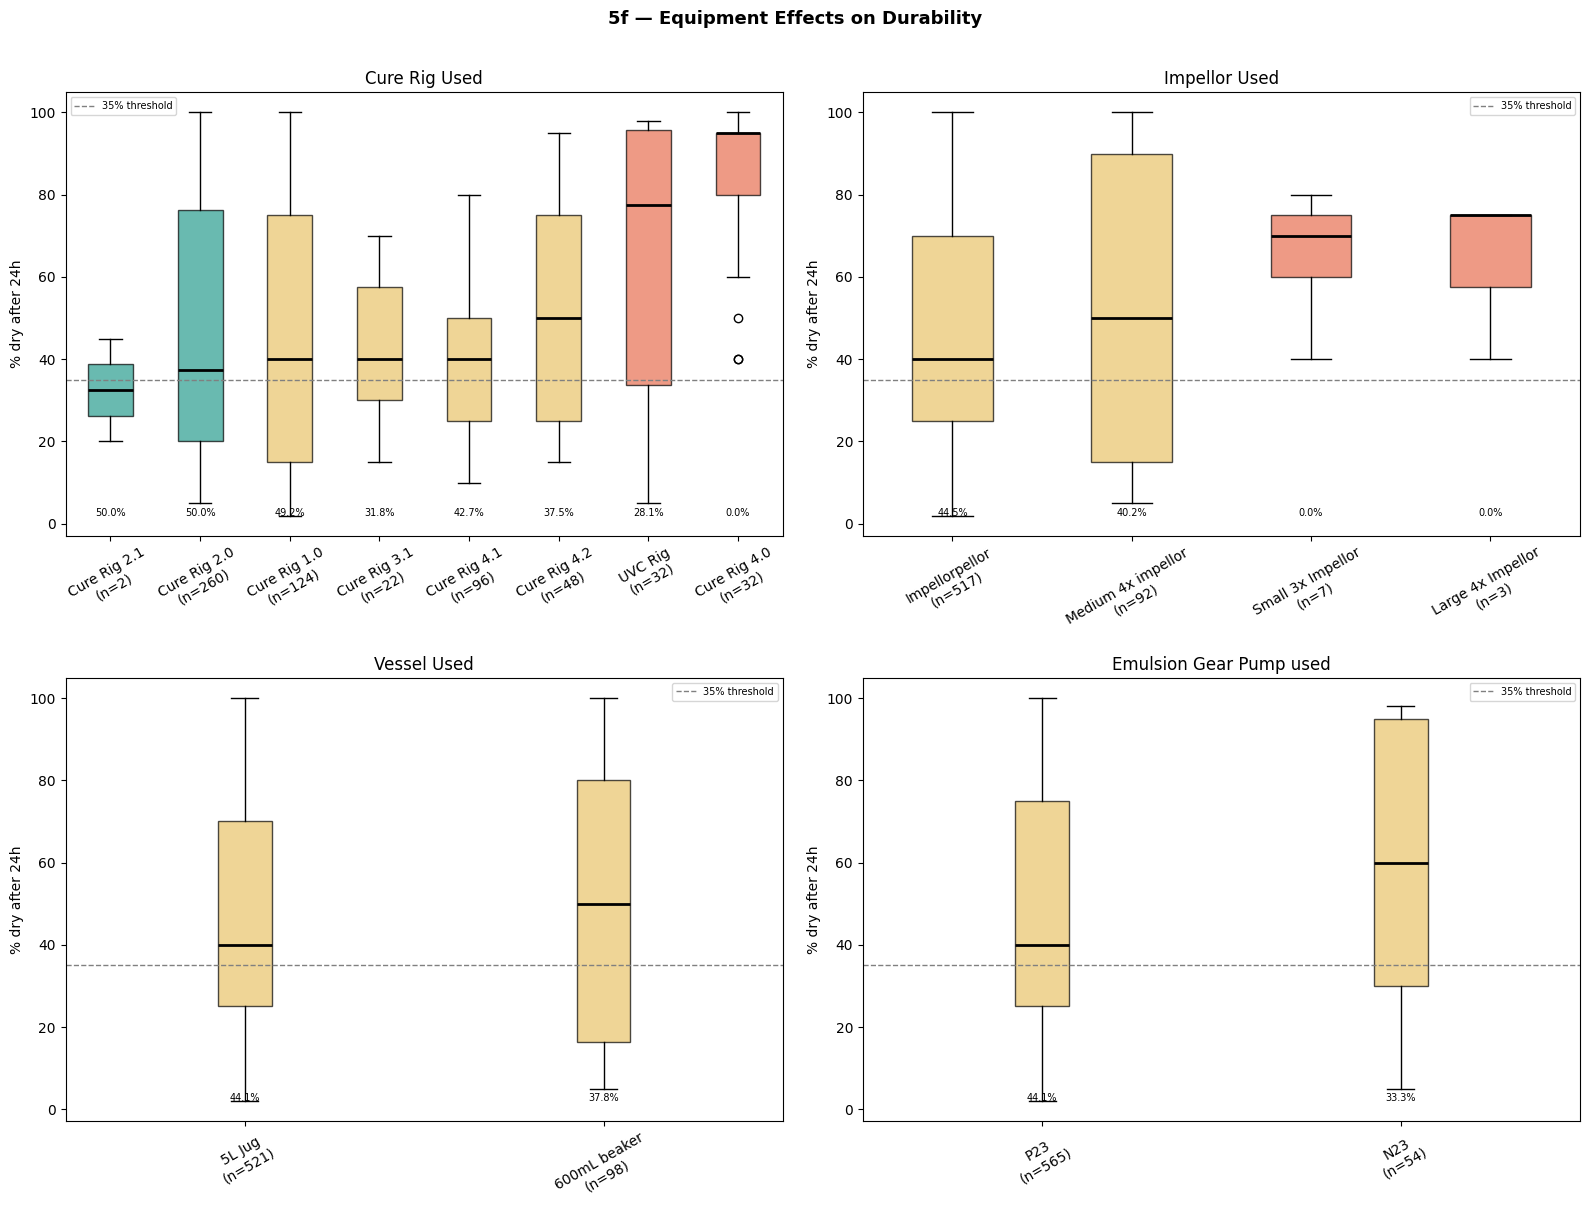


Saved: equipment_effects.png


In [ ]:
t24        = '% dry after 24h in humidity'
equip_cols = ['Cure Rig Used', 'Impellor Used',
              'Vessel Used', 'Emulsion Gear Pump used']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(equip_cols):
    summary = (axf_eda.groupby(col)
               .agg(n=(t24, 'count'),
                    median=(t24, 'median'),
                    pass_rate=('passed', 'mean'))
               .reset_index()
               .sort_values('median'))
    summary['pass_pct'] = (summary['pass_rate'] * 100).round(1)

    print(f"\n{col} — ranked by median score:")
    print(summary[[col, 'n', 'median', 'pass_pct']].to_string(index=False))

    order          = summary[col].astype(str).tolist()
    order_labelled = [f"{f}\n(n={summary[summary[col].astype(str)==f]['n'].values[0]})"
                      for f in order]
    groups         = [axf_eda[axf_eda[col].astype(str) == f][t24].dropna()
                      for f in order]

    bp = axes[i].boxplot(groups, tick_labels=order_labelled,
                         patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    colours_box = ['#2a9d8f' if r >= 0.5 else '#e9c46a' if r >= 0.3
                   else '#e76f51' for r in summary['pass_rate']]
    for patch, c in zip(bp['boxes'], colours_box):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)

    axes[i].axhline(35, color='grey', linestyle='--', linewidth=1,
                    label='35% threshold')
    axes[i].set_title(col)
    axes[i].set_ylabel('% dry after 24h')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=7)

    # Annotate pass rate on each box
    for j, (bar_x, v) in enumerate(zip(range(1, len(order)+1),
                                        summary['pass_pct'])):
        axes[i].text(bar_x, 2, f'{v}%', ha='center',
                     fontsize=7, color='black')

plt.suptitle('5f — Equipment Effects on Durability',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('equipment_effects.png', dpi=150)
plt.show()
print("\nSaved: equipment_effects.png")

#### Findings: Equipment Effects

**Cure Rig** shows the most meaningful equipment effect:
- Cure Rig 2.0 (n=260) and Cure Rig 1.0 (n=124) are the primary rigs
  used, both achieving pass rates close to the dataset average (~50%
  and 49% respectively)
- UVC Rig (n=32, 28%) and Cure Rig 4.0 (n=32, 0%) show notably worse
  outcomes. Cure Rig 4.0's 0% pass rate across 32 runs is a strong
  signal — not a small sample effect. Whether this reflects a
  systematic equipment fault or a confound with the formulations run
  on this rig is worth investigating

**Impellor** is dominated by the standard "Impellorpellor" (n=517,
44.5%). Alternative impellors have very small sample sizes (n=3–92)
making direct comparison unreliable.

**Vessel Used** and **Emulsion Gear Pump** show negligible differences
(≤6 percentage points) as anticipated from the categorical overview —
these variables are not meaningful drivers of durability outcome.

The Cure Rig effect may be a surprise — certain rigs may have been
used exclusively with poor performing UV formulations. This interaction
is worth checking in Section 5g.

### 5g. 24h - 48h Drift by UV Formulation

Having established which UV formulations perform best and worst at 24h
(Section 5d), we now ask: do scores worsen between 24h and 48h, and
does this differ by formulation?

Drift is defined as:

    drift = % dry after 48h − % dry after 24h

A positive drift means the capsule absorbed more moisture between 24h
and 48h. That is, it continued to deteriorate. A drift of zero means the
24h result was stable. A negative drift would mean the capsule dried
further, which is uncommon but possible.

This matters because a formulation with a 24h score may
still be acceptable if it stabilises or may be worse than it appears
if it keeps drifting upward.

UV Formulation — ranked by median drift (higher = more deterioration):
UV formulation   n  median_drift  mean_drift  pass_pct
        AUF092   1          50.0   50.000000       0.0
        AUF279   6          40.0   28.333333      50.0
        AUF144   1          30.0   30.000000       0.0
        AUF091   9          25.0   22.222222      11.1
        AUF146   1          20.0   20.000000       0.0
        AUF191   9          20.0   28.333333      44.4
        AUF069   1          20.0   20.000000       0.0
        AUF090   2          20.0   20.000000      50.0
        AUF141   4          17.5   17.500000       0.0
        AUF075   9          15.0   35.000000     100.0
        AUF143   1          10.0   10.000000       0.0
        AUF277   2          10.0   10.000000      50.0
        AUF134   3          10.0   15.000000      33.3
        AUF139   4           7.5    7.500000       0.0
        AUF198   6           7.5   11.000000      83.3
        AUF096   3           5.0   10.000000     

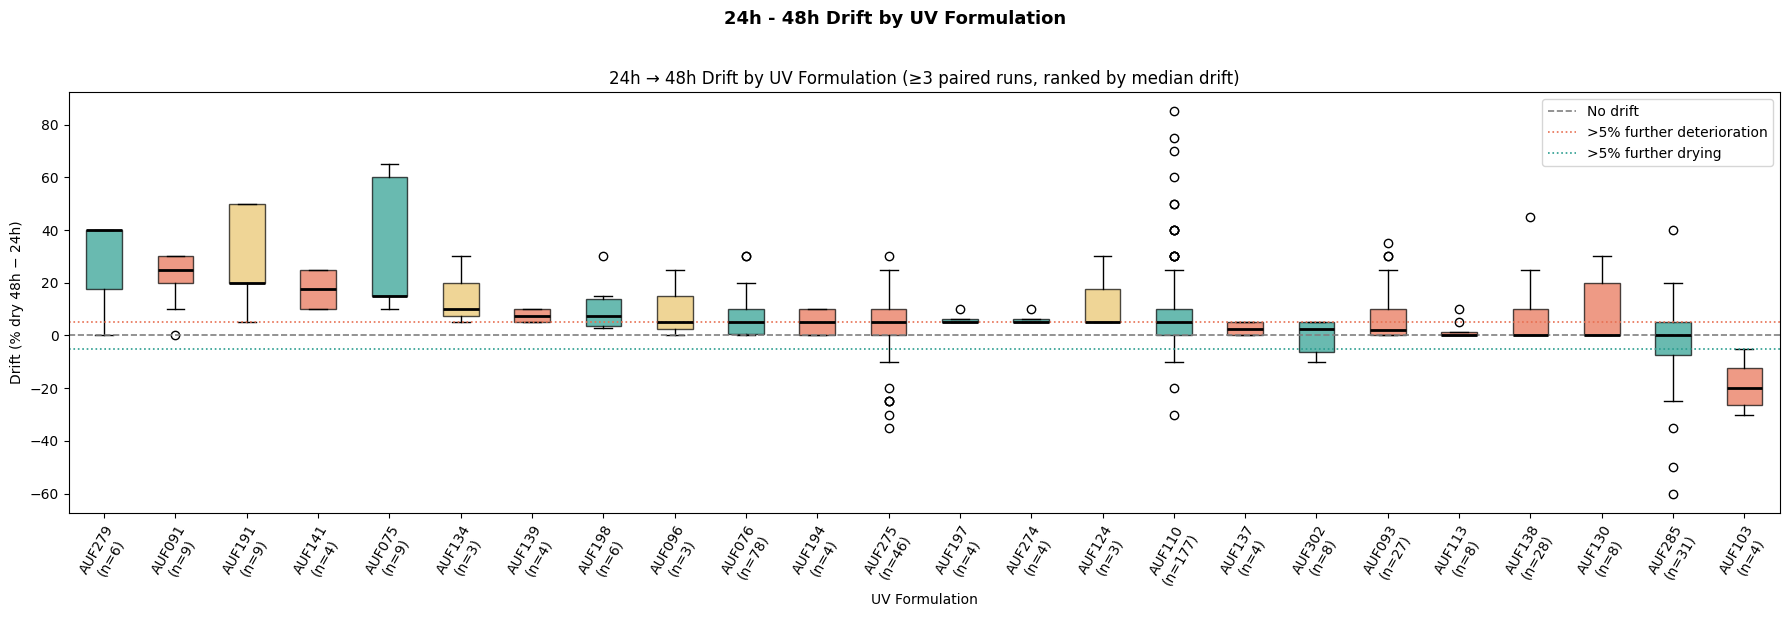

Saved: drift_by_formulation.png


In [ ]:
t24 = '% dry after 24h in humidity'
t48 = '% dry after 2 days in humidity chamber'
uv_col = 'UV formulation'

drift_df = axf_eda[[uv_col, t24, t48, 'passed']].dropna(
    subset=[t24, t48]).copy()
drift_df['drift'] = drift_df[t48] - drift_df[t24]

drift_summary = (drift_df.groupby(uv_col)
                 .agg(n=('drift', 'count'),
                      median_drift=('drift', 'median'),
                      mean_drift=('drift', 'mean'),
                      pass_rate=('passed', 'mean'))
                 .reset_index()
                 .sort_values('median_drift', ascending=False))
drift_summary['pass_pct'] = (drift_summary['pass_rate'] * 100).round(1)

print("UV Formulation — ranked by median drift (higher = more deterioration):")
print(drift_summary[[uv_col, 'n', 'median_drift',
                     'mean_drift', 'pass_pct']].to_string(index=False))

# Plot — only formulations with ≥3 paired runs
plot_df = drift_summary[drift_summary['n'] >= 3]
order   = plot_df[uv_col].tolist()
order_labelled = [f"{f}\n(n={plot_df[plot_df[uv_col]==f]['n'].values[0]})"
                  for f in order]

fig, ax = plt.subplots(figsize=(18, 6))
groups  = [drift_df[drift_df[uv_col] == f]['drift'] for f in order]
bp = ax.boxplot(groups, tick_labels=order_labelled, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))

colours_box = ['#2a9d8f' if r >= 0.5 else '#e9c46a' if r >= 0.3
               else '#e76f51' for r in plot_df['pass_rate']]
for patch, c in zip(bp['boxes'], colours_box):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)

ax.axhline(0,  color='grey',    linestyle='--', linewidth=1.2,
           label='No drift')
ax.axhline(5,  color='#e76f51', linestyle=':',  linewidth=1.2,
           label='>5% further deterioration')
ax.axhline(-5, color='#2a9d8f', linestyle=':',  linewidth=1.2,
           label='>5% further drying')
ax.set_xlabel('UV Formulation')
ax.set_ylabel('Drift (% dry 48h − 24h)')
ax.set_title('24h → 48h Drift by UV Formulation (≥3 paired runs, ranked by median drift)')
ax.tick_params(axis='x', rotation=60)
ax.legend()

plt.suptitle('24h - 48h Drift by UV Formulation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('drift_by_formulation.png', dpi=150)
plt.show()
print("Saved: drift_by_formulation.png")

#### Findings: 24h - 48h Drift by UV Formulation

Drift reveals important distinctions that the 24h score alone misses:

**Formulations that pass at 24h but keep drifting upward:**
- AUF075 (100% pass rate) shows median drift of +15% and mean drift
  of +35% — it passes the 24h threshold but continues to absorb
  moisture. Its durability is time-sensitive
- AUF076 (83% pass, n=78) shows a modest +5% median drift — a
  genuinely stable high performer

**Most stable formulations (drift ≈ 0 or negative):**
- AUF285 (74% pass, n=31) has median drift of 0% and mean drift
  of −4% — it actually dries slightly after 24h. The most
  physically stable formulation in the dataset
- AUF302 (100% pass, n=8) also shows near-zero median drift with
  negative mean drift of −0.6%

**Regular poor performers:**
AUF138, AUF130, AUF093 show 0% median drift not because they are
stable, but because they are already at or near 100% moisture
absorption at 24h — there is nowhere left to drift

**Unusual negative drift — AUF103 (n=4, −20%):**
This formulation appears to dry significantly between 24h and 48h.
The small sample size (n=4) means this finding is revealing only
and warrants further investigation

For modelling purposes, both the 24h score and the drift rate are
informative features — a formulation that passes at 24h but drifts
strongly may be unreliable in practice.

## 6. Why: Ingredient Composition

Section 5 established **what** — which UV formulations pass or fail and at what rates.  
This section asks **why** by joining ingredient level composition data from the Ingredient lookup tables (`uv_cleaned.csv`, `core_cleaned.csv`) against durability outcomes.

The merge notebook (albotherm_02_merge.ipynb) deliberately kept these as separate lookup tables to avoid row explosion. We join them here on demand, for this specific analytical question.

Three analyses:
- **6a** — UV formulation ranking by continuous % dry score  
- **6b** — UV ingredient fingerprint: best vs worst formulations  
- **6c** — Scatter: ingredient concentration vs % dry at 24h  
-

In [ ]:

# Join UV composition onto axf_eda — direct key match, no normalisation needed
df6 = axf_eda.merge(uv_comp, left_on='UV formulation', right_on='Sample', how='left')

# Active UV ingredient columns
uv_ing = [c for c in uv_comp.columns if c not in ['Sample', 'Total']
          and df6[c].sum() > 0]

DRY_COL = '% dry after 24h in humidity'

print(f"Merged rows: {len(df6)} | Active UV ingredients: {len(uv_ing)}")
print(f"UV match rate: {df6['Sample'].notna().mean():.1%}")

Merged rows: 619 | Active UV ingredients: 24
UV match rate: 100.0%


### 6a. UV Formulation Ranking — Continuous % Dry Score

Formulations ranked by mean % dry at 24h (lower = better).  
Minimum 3 runs required for inclusion. The 35% threshold separates  
the passing tier from failing.

In [ ]:
form_summary = df6.groupby('UV formulation').agg(
    n          = (DRY_COL, 'count'),
    mean_dry   = (DRY_COL, 'mean'),
    median_dry = (DRY_COL, 'median'),
    std_dry    = (DRY_COL, 'std'),
    **{ing: (ing, 'first') for ing in uv_ing}
).reset_index()

form_summary = form_summary[form_summary['n'] >= 3].sort_values('mean_dry')

print(form_summary[['UV formulation','n','mean_dry','median_dry','std_dry']].to_string())

   UV formulation    n   mean_dry  median_dry    std_dry
1          AUF075   10  11.000000        12.5   4.594683
27         AUF274    4  17.500000        17.5   6.454972
32         AUF302    8  20.625000        20.0   6.232117
2          AUF076   82  21.646341        20.0  13.057680
31         AUF285   43  23.837209        20.0  14.093109
34         AUF333    6  25.833333        25.0   5.845226
25         AUF197    4  28.750000        32.5  13.149778
33         AUF331    4  35.000000        35.0   4.082483
9          AUF110  213  46.159624        40.0  26.957564
12         AUF124    3  50.000000        65.0  30.413813
8          AUF103   22  50.454545        50.0  17.654697
30         AUF279   14  52.500000        50.0  16.727453
14         AUF134    3  53.333333        40.0  32.145503
7          AUF096    4  53.750000        55.0  18.874586
28         AUF275   59  55.847458        50.0  20.618717
23         AUF191    9  57.222222        80.0  32.414417
24         AUF194    4  57.5000

### 6b. UV Ingredient Fingerprint — Best vs Worst Formulations

Top 5 formulations (lowest mean % dry) vs bottom 5 (highest mean % dry).  
Mean ingredient concentration per group compared — delta reveals which  
ingredients are systematically associated with durability outcome.

In [ ]:
top_best = form_summary.head(5)['UV formulation'].tolist()
top_worst = form_summary.tail(5)['UV formulation'].tolist()

df6['group'] = np.where(df6['UV formulation'].isin(top_best),  'Best (low dry)',
               np.where(df6['UV formulation'].isin(top_worst), 'Worst (high dry)', None))

profile = df6[df6['group'].notna()].groupby('group')[uv_ing].mean().T
profile['delta'] = profile.get('Best (low dry)', 0) - profile.get('Worst (high dry)', 0)
profile = profile[profile.abs().max(axis=1) > 0.5].sort_values('delta', ascending=False)

print("=== Ingredients HIGHER in Best formulations (low % dry) ===")
print(profile[profile['delta'] > 0][['Best (low dry)','Worst (high dry)','delta']].to_string())
print("\n=== Ingredients HIGHER in Worst formulations (high % dry) ===")
print(profile[profile['delta'] < 0][['Best (low dry)','Worst (high dry)','delta']].to_string())

=== Ingredients HIGHER in Best formulations (low % dry) ===
group                          Best (low dry)  Worst (high dry)      delta
TPGDA                               43.642857         18.326761  25.316097
ESBOA                               26.496599          7.746479  18.750120
Miramer PU2100NT                    16.479592          0.000000  16.479592
Photocryl DP408NT (40% DPGDA)        1.292517          0.000000   1.292517
IDA                                  1.238095          0.000000   1.238095
JRcure1919                           0.731293          0.000000   0.731293
JRcure1607                           0.731293          0.000000   0.731293
Omnirad MBF - Type II                3.122449          2.464789   0.657660

=== Ingredients HIGHER in Worst formulations (high % dry) ===
group                  Best (low dry)  Worst (high dry)      delta
Radactive SF                 0.136054          0.788732  -0.652678
Omnirad 1173 - Type I        0.333333          1.014085  -0.680751
T

### Findings — UV Ingredient Fingerprint

Comparing the 5 best and 5 worst UV formulations by mean % dry at 24h
reveals two distinct ingredient profiles. The split is clean and consistent.

---

#### What the best formulations have more of

| Ingredient | Best avg | Worst avg | Difference |
|---|---|---|---|
| TPGDA | 43.6% | 18.3% | +25.3 |
| ESBOA | 26.5% | 7.7% | +18.8 |
| Miramer PU2100NT | 16.5% | 0.0% | +16.5 |

Three ingredients are systematically higher in the best formulations.
**Miramer PU2100NT** is the most obvious — present at ~16% in the best,
completely absent from all worst formulations.

In another word: these three ingredients appear to work together to
build a shell that stays intact under humidity. We pronounce them as
the **flexible structural backbone** of the coating.

---

#### What the worst formulations have more of

| Ingredient | Best avg | Worst avg | Difference |
|---|---|---|---|
| SR833S | 0.0% | 45.3% | −45.3 |
| SR399 | 0.0% | 9.5% | −9.5 |
| Miramer PU2560 | 3.3% | 11.3% | −7.9 |

**SR833S is the single strongest signal in the dataset.** It makes up
~45% of the worst formulations by weight and is entirely absent from
the best. SR399 follows the same pattern.

Both are absent from good formulations and dominant in bad ones —
that is not a subtle correlation, it is a structural split. These
ingredients appear to produce a shell that becomes permanently dry
under humidity rather than continuing to switch.

---

#### Summary

> The data separates UV formulations into two chemically distinct families.
> One family (TPGDA + ESBOA + PU2100NT) consistently scores below 35% dry.
> The other (SR833S + SR399) consistently scores above 87% dry.
> **SR833S concentration is the strongest single predictor of failure
> found in this dataset.**

---

#### AUF110 — the outlier that needs explaining

AUF110 represents **34% of all production runs** (n = 213) and sits
at a mean of 46% dry with a standard deviation of 27 — by far the
widest spread in the dataset. It does not belong cleanly to either
ingredient family above. Its high run-to-run variability points to
**process parameters** (curing energy, viscosity, flow rate) as the
likely driver of inconsistency rather than the formulation itself.
AUF110 is the primary focus for Section 7.

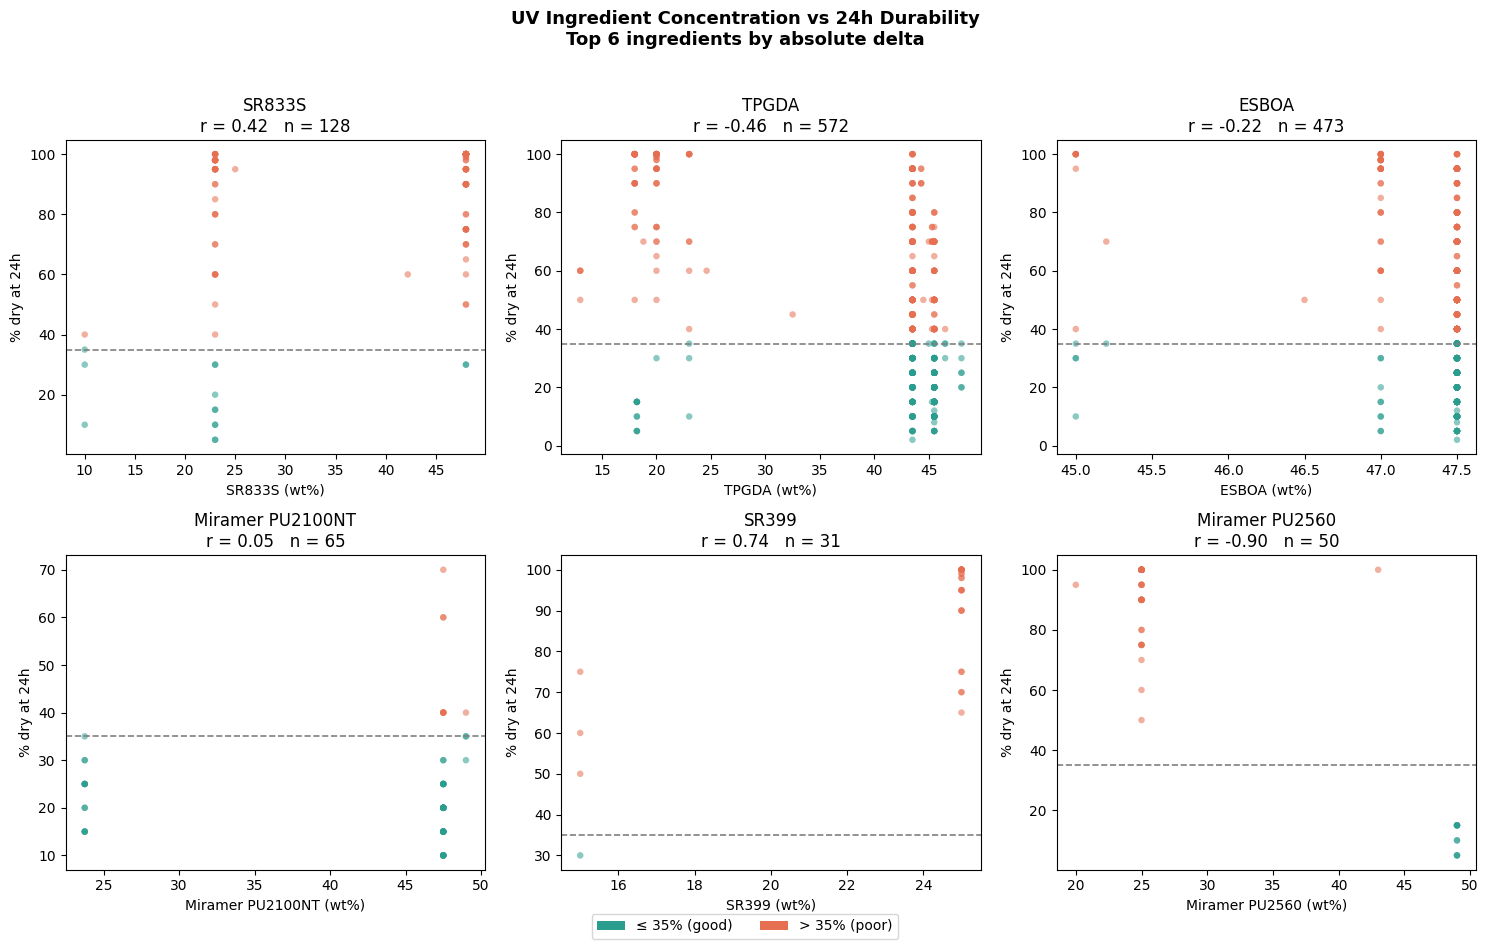

Saved uv_ingredient_scatter.png


In [ ]:

top_ings = profile['delta'].abs().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, ing in enumerate(top_ings):
    subset = df6[[ing, DRY_COL]].dropna()
    subset = subset[subset[ing] > 0]
    colours = subset[DRY_COL].apply(lambda x: '#2a9d8f' if x <= 35 else '#e76f51')

    axes[i].scatter(subset[ing], subset[DRY_COL],
                    c=colours, alpha=0.55, s=22, edgecolors='none')
    axes[i].axhline(35, color='grey', linestyle='--', linewidth=1.2)

    corr = subset[ing].corr(subset[DRY_COL])
    axes[i].set_xlabel(f'{ing[:30]} (wt%)')
    axes[i].set_ylabel('% dry at 24h')
    axes[i].set_title(f'{ing[:30]}\nr = {corr:.2f}   n = {len(subset)}')

legend_elements = [Patch(facecolor='#2a9d8f', label='≤ 35% (good)'),
                   Patch(facecolor='#e76f51', label='> 35% (poor)')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('UV Ingredient Concentration vs 24h Durability\nTop 6 ingredients by absolute delta',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('uv_ingredient_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved uv_ingredient_scatter.png")

## 7. Drift Analysis & AUF110 Deep Dive

Section 6 identified UV formulation composition as the primary driver
of durability outcome — the ingredient split between SR833S and
TPGDA/ESBOA explained the difference between consistent failures and
consistent passers.

But two formulations sit outside that story and demand their own
investigation:

- **AUF110** — 34% of all production runs (213 of 619), mean % dry =
  46%, std = 27, range 2–100%. Same formulation, wildly different
  outcomes run to run. The ingredient profile does not explain this.

- **AUF075** — best mean 24h score in the entire dataset (11% dry,
  n=10), yet drifts +35 points to 47% by 48h. On paper the top
  performer; in practice unreliable.

Both look like problems. This section argues they are not —
**they are the two most promising formulations in the dataset,
being run with the wrong process settings.**

This section answers that in three steps:
- **7a** — Drift by formulation family and starting zone: who drifts,
  how much, and does the starting score predict it?
- **7b** — AUF110 process parameter analysis: which settings drive
  both the 24h variance and the drift?
- **7c** — Actionable process window: what targets should Albotherm
  use to unlock AUF110 and AUF075's true potential?

---

### Note: Revisiting Section 5a

Section 5a found process parameters weakly correlated with durability
across the full dataset (all |r| < 0.20). That finding was correct —
but it was answering the wrong question.

The full dataset mixes brittle and flexible formulations together.
A brittle SR833S run scoring 93% dry and a flexible TPGDA run scoring
12% dry sit in the same regression — the formulation signal dominates
and the process signal disappears.

Isolated to AUF110 alone (n=213), the same question produces a
completely different answer:

| Parameter | r across all data | r within AUF110 only |
|---|---|---|
| Flow Rate Ratio | weak | **+0.52** |
| Dispersed Flow Rate (mL/min) | weak | **−0.45** |
| UV Power (J s-1) | +0.12 | **+0.45** |

This is a classic pattern in data analysis — a relationship invisible
at the aggregate level becomes clear once the data is properly grouped.

**The correct interpretation of the full dataset:**

> Formulation sets the ceiling.
> Process determines whether you reach it.
> A bad formulation (SR833S) fails regardless of process.
> A capable formulation (AUF110, AUF075) can look like a failure
> when run with the wrong process settings — and like the best
> formulation in the portfolio when run correctly.

### 7a. Drift by formulation family and starting zone: who drifts,
  how much, and does the starting score predict it?

In [ ]:
# Label Families & Compute Drift

DRY_24  = '% dry after 24h in humidity'
DRY_48  = '% dry after 2 days in humidity chamber'

brittle_family    = ['AUF093','AUF138','AUF137','AUF130','AUF113','AUF141']
flexible_family   = ['AUF075','AUF076','AUF274','AUF302','AUF285']
process_sensitive = ['AUF110']

def label_family(uv):
    if uv in brittle_family:    return 'Brittle (SR833S)'
    if uv in flexible_family:   return 'Flexible (TPGDA/ESBOA)'
    if uv in process_sensitive: return 'Process-Sensitive (AUF110)'
    return 'Other'

df6 = axf_eda.copy()
df6['family'] = df6['UV formulation'].apply(label_family)
df6['drift']  = df6[DRY_48] - df6[DRY_24]

family_summary = df6.groupby('family')[[DRY_24, 'drift']].agg(
    ['mean','std','count'])
print(family_summary)

                           % dry after 24h in humidity                   \
                                                  mean        std count   
family                                                                    
Brittle (SR833S)                             91.569620  13.442836    79   
Flexible (TPGDA/ESBOA)                       21.394558  12.860451   147   
Other                                        56.938889  25.466631   180   
Process-Sensitive (AUF110)                   46.159624  26.957564   213   

                                drift                   
                                 mean        std count  
family                                                  
Brittle (SR833S)             7.227848  10.505126    79  
Flexible (TPGDA/ESBOA)       5.292308  15.297285   130  
Other                       10.684685  16.786348   111  
Process-Sensitive (AUF110)   8.887006  14.563681   177  


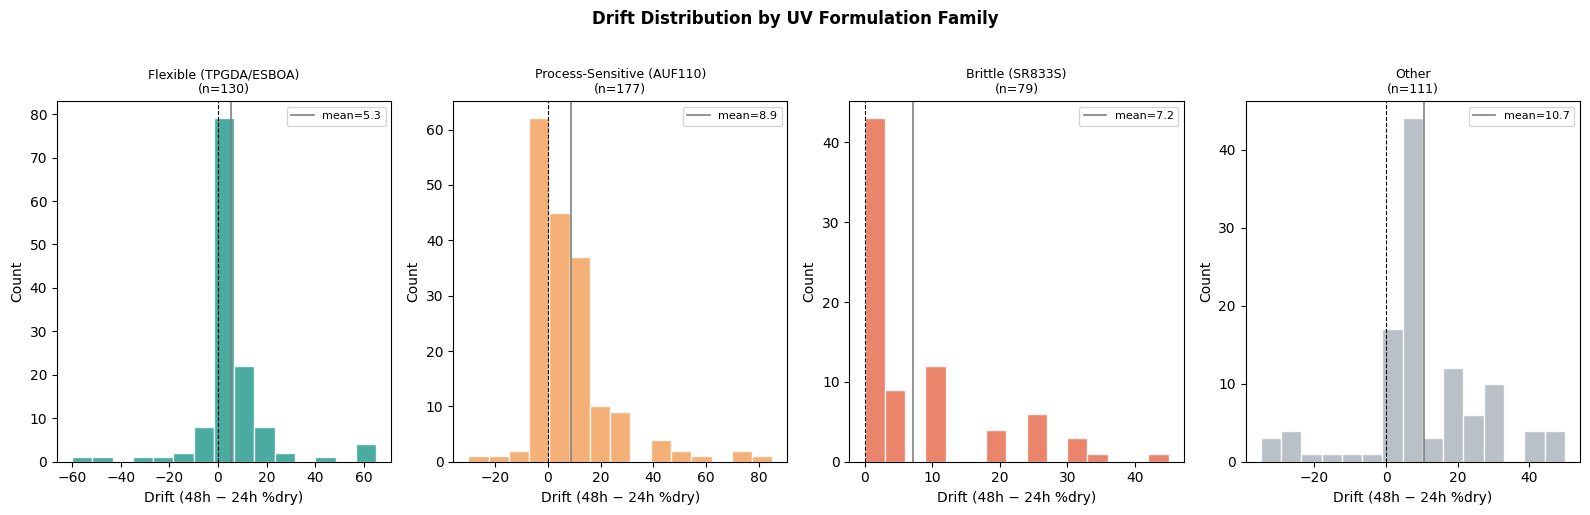

Saved drift_by_family.png


In [ ]:
# Drift Distribution by Family

families = ['Flexible (TPGDA/ESBOA)','Process-Sensitive (AUF110)',
            'Brittle (SR833S)','Other']
colours  = ['#2a9d8f','#f4a261','#e76f51','#adb5bd']

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)

for ax, fam, col in zip(axes, families, colours):
    subset = df6[df6['family'] == fam]['drift'].dropna()
    ax.hist(subset, bins=15, color=col, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(subset.mean(), color='grey', linewidth=1.2,
               label=f'mean={subset.mean():.1f}')
    ax.set_title(f'{fam}\n(n={len(subset)})', fontsize=9)
    ax.set_xlabel('Drift (48h − 24h %dry)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Drift Distribution by UV Formulation Family',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('drift_by_family.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved drift_by_family.png")

In [ ]:
#Drift by 24h Starting Zone
bins   = [0, 20, 35, 60, 101]
labels = ['Clean (0–20)','Borderline (20–35)','Marginal (35–60)','Failed (60–100)']

df6_drift = df6[[DRY_24, DRY_48, 'drift', 'family',
                 'UV formulation']].dropna(subset=['drift'])
df6_drift['zone_24h'] = pd.cut(df6_drift[DRY_24], bins=bins,
                                labels=labels, right=False)

zone_summary = df6_drift.groupby(
    ['family','zone_24h'], observed=True)['drift'].agg(
    ['mean','std','count']).reset_index()
print(zone_summary.to_string())

                        family            zone_24h       mean        std  count
0             Brittle (SR833S)  Borderline (20–35)  10.000000        NaN      1
1             Brittle (SR833S)    Marginal (35–60)  45.000000        NaN      1
2             Brittle (SR833S)     Failed (60–100)   6.701299   9.700875     77
3       Flexible (TPGDA/ESBOA)        Clean (0–20)   8.953125  15.182937     64
4       Flexible (TPGDA/ESBOA)  Borderline (20–35)   3.720930   6.645176     43
5       Flexible (TPGDA/ESBOA)    Marginal (35–60)   4.736842  14.669856     19
6       Flexible (TPGDA/ESBOA)     Failed (60–100) -33.750000  30.923292      4
7                        Other        Clean (0–20)   9.000000   7.193747      9
8                        Other  Borderline (20–35)  19.687500  19.014797     16
9                        Other    Marginal (35–60)  12.333333  14.003284     30
10                       Other     Failed (60–100)   7.500000  17.837652     56
11  Process-Sensitive (AUF110)        Cl

### Findings — 7a Drift Analysis

#### By family

| Family | Mean % dry 24h | Mean drift | n |
|---|---|---|---|
| Flexible (TPGDA/ESBOA) | 21.4% | +5.3 | 130 |
| Process-Sensitive (AUF110) | 46.2% | +8.9 | 177 |
| Brittle (SR833S) | 91.6% | +7.2 | 79 |
| Other | 56.9% | +10.7 | 111 |

The brittle family does not drift — it starts at 91% and stays there.
No room left to worsen. The flexible family has the tightest drift
distribution. AUF110 has the widest — range −20 to +80.

#### By starting zone

| Family | Clean 0–20% | Borderline 20–35% | Marginal 35–60% | Failed 60–100% |
|---|---|---|---|---|
| Flexible | +8.9 (n=64) | +3.7 (n=43) | +4.7 (n=19) | **−33.8 (n=4)** |
| AUF110 | **+14.6 (n=31)** | +11.3 (n=46) | +6.7 (n=48) | +5.4 (n=52) |
| Brittle | — | — | — | +6.7 (n=77) |
| Other | +9.0 (n=9) | +19.7 (n=16) | +12.3 (n=30) | +7.5 (n=56) |

**Flexible family** — drift falls as starting score worsens. The 4 runs
already failed at 24h self-correct by −33.8 by 48h (delayed curing).
When this family passes at 24h it stays passing. Most stable family overall.

**AUF110** — drift is highest in the clean zone (+14.6). A run scoring
well at 24h on AUF110 is the *least* stable outcome in the dataset.
The 24h test alone is not sufficient to qualify AUF110. **48h reading
is essential for this formulation.**


**Other — borderline zone is the highest risk group** — runs scoring
20–35% at 24h drift nearly +20 by 48h. These borderline Other runs
are the most likely to be incorrectly passed under the current
24h only QC process.

**AUF075** — best mean 24h score in the dataset (11% dry) but
drifted +35 by 48h. Passes QC at 24h but likely fails in 48 use.
Flag for mandatory 48h testing.

7b will investigate.

### 7b.  AUF110, flexible Family process parameter analysis

7a showed that AUF110's drift is highest when it starts clean, and that
its 24h variance (std = 27) cannot be explained by formulation design —
the ingredient composition is fixed across all 213 runs.

The only thing that changes run to run is how AUF110 is processed.
This section tests all 15 available process parameters against both
the 24h score and the drift to identify which settings are driving
the instability.

In [ ]:
# AUF110 process parameter Correlations with 24h Score

process_cols_full = [
    'Curing Energy (kJ g-1)', 'UV Power (J s-1)', 'UV viscosity (cP)',
    'Core Viscosity (cP)', 'Emulsion viscosity (cP)', 'Impellor Speed (rpm)',
    'Dispersed Flow Rate (mL/min)', 'Continuous Flow Rate (mL/min)',
    'Flow Rate Ratio', 'Membrane Used (µm)', 'Insert used (mm)',
    'Length of curing tubing (m)', 'Core Loading (%)',
    'Amount of UV Used (g)', 'Amount of Core Used (g)'
]
available = [c for c in process_cols_full if c in axf_eda.columns]

auf110 = axf_eda[axf_eda['UV formulation'] == 'AUF110'].copy()
auf110['drift'] = auf110[DRY_48] - auf110[DRY_24]
auf110_clean = auf110[available + [DRY_24, DRY_48, 'drift']].dropna(subset=[DRY_24])

corr_24h = auf110_clean[available].corrwith(auf110_clean[DRY_24]).sort_values()
print("=== AUF110 — correlations with % dry at 24h ===")
print(corr_24h.to_string())

=== AUF110 — correlations with % dry at 24h ===
Dispersed Flow Rate (mL/min)    -0.451597
Length of curing tubing (m)     -0.429785
UV viscosity (cP)               -0.294954
Amount of UV Used (g)           -0.258690
Insert used (mm)                -0.250652
Amount of Core Used (g)         -0.212211
Impellor Speed (rpm)            -0.039390
Core Viscosity (cP)              0.001640
Curing Energy (kJ g-1)           0.015297
Emulsion viscosity (cP)          0.088281
Membrane Used (µm)               0.103117
Core Loading (%)                 0.120586
Continuous Flow Rate (mL/min)    0.395667
UV Power (J s-1)                 0.454688
Flow Rate Ratio                  0.520911


In [ ]:
# AUF110 Correlations with Drift
corr_drift = auf110_clean[available].corrwith(
    auf110_clean['drift']).sort_values()
print("=== AUF110 — correlations with drift (48h − 24h) ===")
print(corr_drift.to_string())

=== AUF110 — correlations with drift (48h − 24h) ===
Flow Rate Ratio                 -0.403554
Continuous Flow Rate (mL/min)   -0.269246
UV Power (J s-1)                -0.184968
Curing Energy (kJ g-1)          -0.121060
Core Loading (%)                 0.030523
Impellor Speed (rpm)             0.076437
Membrane Used (µm)               0.093253
Core Viscosity (cP)              0.098212
Length of curing tubing (m)      0.170568
Amount of UV Used (g)            0.180568
Amount of Core Used (g)          0.192022
Insert used (mm)                 0.226026
Emulsion viscosity (cP)          0.307880
UV viscosity (cP)                0.318741
Dispersed Flow Rate (mL/min)     0.412768


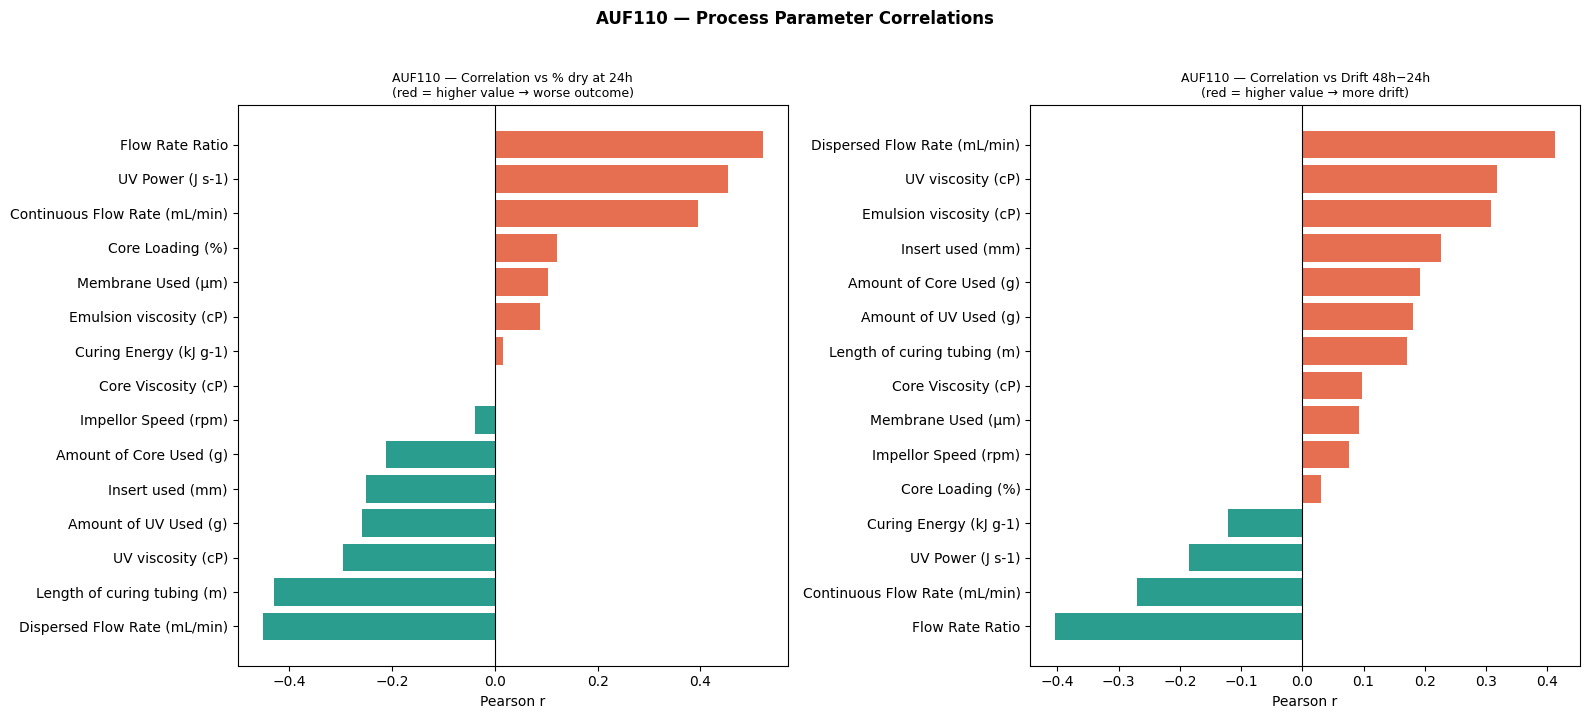

Saved auf110_process_corr.png


In [ ]:
# AUF110 Dual Correlation Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, corr, title in zip(
    axes,
    [corr_24h, corr_drift],
    ['vs % dry at 24h\n(red = higher value → worse outcome)',
     'vs Drift 48h−24h\n(red = higher value → more drift)']):

    colours = ['#2a9d8f' if v < 0 else '#e76f51' for v in corr.values]
    ax.barh(corr.index.str[:38], corr.values, color=colours)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Pearson r')
    ax.set_title(f'AUF110 — Correlation {title}', fontsize=9)

plt.suptitle('AUF110 — Process Parameter Correlations',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('auf110_process_corr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved auf110_process_corr.png")

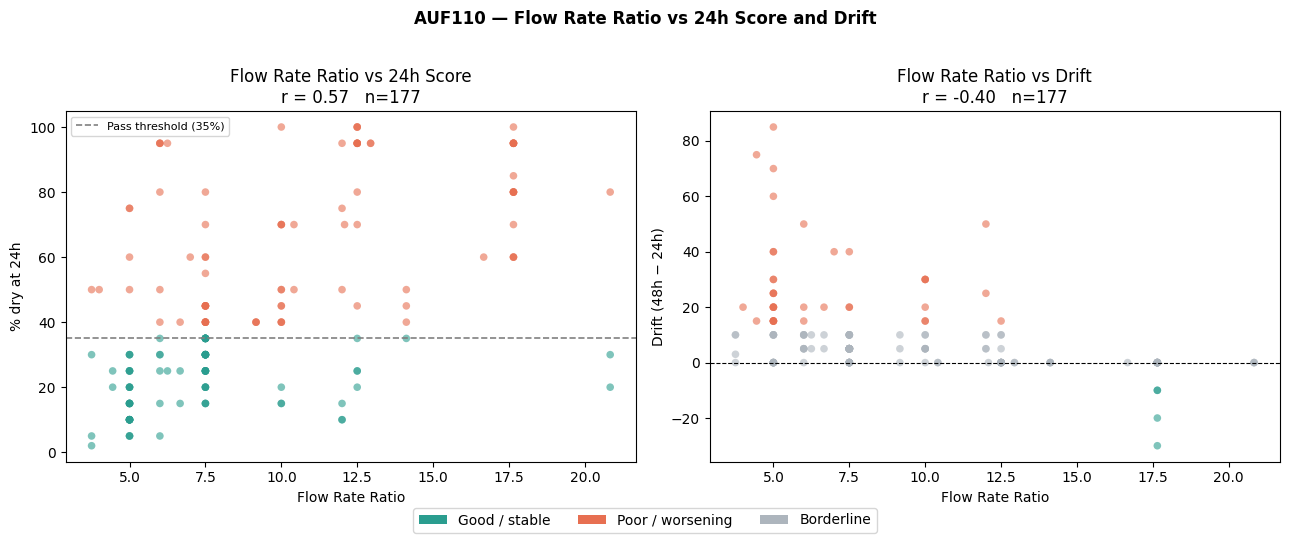

Saved auf110_flowrate_drift.png


In [ ]:
# Flow Rate Ratio Scatter (24h + Drift)

auf110_plot = auf110_clean[['Flow Rate Ratio', DRY_24, 'drift']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — Flow Rate Ratio vs 24h score
c1 = auf110_plot[DRY_24].apply(
    lambda x: '#2a9d8f' if x <= 35 else '#e76f51')
axes[0].scatter(auf110_plot['Flow Rate Ratio'], auf110_plot[DRY_24],
                c=c1, alpha=0.6, s=30, edgecolors='none')
axes[0].axhline(35, color='grey', linestyle='--', linewidth=1.2,
                label='Pass threshold (35%)')
r0 = auf110_plot['Flow Rate Ratio'].corr(auf110_plot[DRY_24])
axes[0].set_xlabel('Flow Rate Ratio')
axes[0].set_ylabel('% dry at 24h')
axes[0].set_title(f'Flow Rate Ratio vs 24h Score\nr = {r0:.2f}   n={len(auf110_plot)}')
axes[0].legend(fontsize=8)

# Right — Flow Rate Ratio vs Drift
c2 = auf110_plot['drift'].apply(
    lambda x: '#e76f51' if x > 10 else '#2a9d8f' if x < -5 else '#adb5bd')
axes[1].scatter(auf110_plot['Flow Rate Ratio'], auf110_plot['drift'],
                c=c2, alpha=0.6, s=30, edgecolors='none')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
r1 = auf110_plot['Flow Rate Ratio'].corr(auf110_plot['drift'])
axes[1].set_xlabel('Flow Rate Ratio')
axes[1].set_ylabel('Drift (48h − 24h)')
axes[1].set_title(f'Flow Rate Ratio vs Drift\nr = {r1:.2f}   n={len(auf110_plot)}')

legend = [mpatches.Patch(facecolor='#2a9d8f', label='Good / stable'),
          mpatches.Patch(facecolor='#e76f51', label='Poor / worsening'),
          mpatches.Patch(facecolor='#adb5bd', label='Borderline')]
fig.legend(handles=legend, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.04))
plt.suptitle('AUF110 — Flow Rate Ratio vs 24h Score and Drift',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('auf110_flowrate_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved auf110_flowrate_drift.png")

In [ ]:
# Flexible Family Process Delta (High Drift vs Stable)

flex_runs = axf_eda[axf_eda['UV formulation'].isin(flexible_family)].copy()
flex_runs['drift'] = flex_runs[DRY_48] - flex_runs[DRY_24]
flex_runs = flex_runs.dropna(subset=['drift'])

flex_runs['drift_group'] = np.where(
    flex_runs['drift'] > 15, 'High drift (>15)',
    np.where(flex_runs['drift'] < 5, 'Stable (<5)', None))

flex_process = flex_runs[flex_runs['drift_group'].notna()]
drift_delta = flex_process.groupby('drift_group')[available].mean().T
drift_delta['delta'] = (drift_delta.get('High drift (>15)', 0)
                        - drift_delta.get('Stable (<5)', 0))

# Exclude UV Power — implausible delta, data quality flag
drift_delta = drift_delta[drift_delta.index != 'UV Power (J s-1)']
drift_delta = drift_delta[drift_delta['delta'].abs() > 0.5].sort_values(
    'delta', ascending=False)

print(drift_delta[['High drift (>15)', 'Stable (<5)', 'delta']].to_string())

drift_group                    High drift (>15)  Stable (<5)       delta
Core Viscosity (cP)                 8474.909091  7886.638298  588.270793
Emulsion viscosity (cP)              992.680000   551.800000  440.880000
UV viscosity (cP)                    450.218182   307.404255  142.813926
Impellor Speed (rpm)                 188.727273    91.638298   97.088975
Length of curing tubing (m)           40.680000    25.523617   15.156383
Flow Rate Ratio                       13.181818     7.586961    5.594857
Continuous Flow Rate (mL/min)        260.000000   263.404255   -3.404255
Dispersed Flow Rate (mL/min)          23.454545    33.570213  -10.115667
Amount of Core Used (g)              671.163636  1067.387234 -396.223598
Amount of UV Used (g)               1565.454545  2493.191489 -927.736944


### Findings

#### What drives AUF110's 24h score?

| Parameter | r with 24h score | Direction |
|---|---|---|
| **Flow Rate Ratio** | +0.57 | Strongest signal — higher ratio → worse outcome |
| **UV Power (J s-1)** | +0.45 | Higher power → worse |
| **Continuous Flow Rate (mL/min)** | +0.40 | Higher → worse |
| **Dispersed Flow Rate (mL/min)** | −0.45 | Higher → better outcome |
| **Length of curing tubing (m)** | −0.43 | Longer → better |
| UV viscosity (cP) | −0.29 | Higher → better |
| Curing Energy (kJ g-1) | +0.02 | No signal |
| Core Viscosity (cP) | +0.002 | No signal |

#### What drives AUF110's drift?

| Parameter | r with drift | Direction |
|---|---|---|
| **Dispersed Flow Rate (mL/min)** | +0.41 | Higher → more drift |
| **Flow Rate Ratio** | −0.40 | Higher ratio → less drift |
| UV viscosity (cP) | +0.32 | Higher → more drift |
| Emulsion viscosity (cP) | +0.31 | Higher → more drift |


What is driving AUF110's inconsistency?

AUF110's ingredient recipe never changes across all 213 runs.
So why do results vary so much? This section tested all 15 process
parameters to find out.

---

Three process settings — Flow Rate Ratio, Dispersed Flow Rate, and
Impellor Speed — explain most of the variation in both 24h score and
drift. The formulation is not the problem. The process is.

---

#### What controls the 24h score?

The 24h score tells us how well the capsule shell formed in the first place.

- **Flow Rate Ratio (r = +0.57)** — the strongest signal.
  Higher ratio = worse capsules at 24h. This one setting alone
  explains a large portion of why some runs fail immediately.

- **Dispersed Flow Rate (r = −0.45)** — higher dispersed flow = better capsules.
  This is the rate at which the core material is pushed through the membrane.
  Faster dispersed flow produces better-formed shells.

- **UV Power (r = +0.45)** — higher power = worse outcome.
  Too much UV energy during curing appears to damage the shell.

- **Continuous Flow Rate (r = +0.40)** — higher = worse.
  This is the carrier fluid. Too fast and the droplets don't form properly.

- **Length of curing tubing (r = −0.43)** — longer = better.
  More tubing gives the capsule more time to cure before collection.

- **Curing Energy and Core Viscosity** — no signal whatsoever.
  These parameters do not predict outcome at all.

---

#### What controls drift (48h − 24h)?

Drift tells us whether a capsule that looked good at 24h holds up over time.

- **Flow Rate Ratio (r = −0.40)** — higher ratio = less drift.
  But this is not good news — see below.

- **Dispersed Flow Rate (r = +0.41)** — higher dispersed flow = more drift.
  The same setting that helps 24h score actually increases drift risk.

- **UV viscosity and Emulsion viscosity** — both show moderate drift signal.
  Higher viscosity formulations are more prone to drifting.

---

#### Why do Flow Rate Ratio and Dispersed Flow Rate pull in opposite directions?

This is the most important finding in this section.

The same settings that make capsules look good at 24h
also make them more likely to drift by 48h — and vice versa.
This reveals two distinct failure modes:

**Failure Mode A — Shell never forms properly (Stable Failure)**
> Flow Rate Ratio is too high. Dispersed flow is too low.
> The capsule is already failing at 24h (high % dry).
> By 48h it has not changed much — because there was nothing
> left to lose. It looks "stable" but it was broken from the start.

**Failure Mode B — Shell forms but doesn't hold (Unstable Pass)**
> Flow Rate Ratio is low. Dispersed flow is high.
> The capsule looks excellent at 24h (low % dry, within spec).
> But the shell is too fragile. By 48h it has deteriorated badly.
> This is the most dangerous failure — it passes quality checks
> and then fails in the field.

---

#### Does the flexible family show the same pattern?

Yes — exactly the same.

Comparing flexible family runs with high drift (>15) against
stable runs (drift <5) shows the same three parameters in charge:

| Setting | Stable runs | High-drift runs |
|---|---|---|
| Flow Rate Ratio | 7.6 | 13.2 |
| Dispersed Flow Rate (mL/min) | 33.6 | 23.5 |
| Impellor Speed (rpm) | 91.6 | 188.7 |

The flexible family becomes unstable under the same wrong settings
as AUF110. This is not a coincidence.

---

#### conclusion

> The formulations are not the problem.
> AUF110, AUF075, and the flexible family are all capable of
> producing good, stable capsules.
> They just need to be run within the right process window.
>
> That window — the exact target values for Flow Rate Ratio,
> Dispersed Flow Rate, and Impellor Speed — is defined in 7c.

---


### 7c. Defining the process window

7b showed that AUF110 does not have a formulation problem — it has a
process window problem. The same three settings repeatedly separate
good runs from bad ones: **Flow Rate Ratio, Dispersed Flow Rate, and
Impellor Speed**.

This section turns that insight into an actionable operating window:
the range of settings where capsules both **pass at 24h** and **stay
stable at 48h**.

In [ ]:
# Build pass/stable flags for AUF110
auf110 = axf_eda[axf_eda['UV formulation'] == 'AUF110'].copy()
auf110['drift'] = auf110[DRY_48] - auf110[DRY_24]

auf110_win = auf110[['Flow Rate Ratio', 'Dispersed Flow Rate (mL/min)',
                     'Impellor Speed (rpm)', DRY_24, 'drift']].dropna()

auf110_win['status'] = np.where(
    (auf110_win[DRY_24] <= 35) & (auf110_win['drift'] <= 10), 'Pass + stable',
    np.where((auf110_win[DRY_24] <= 35) & (auf110_win['drift'] > 10), 'Pass + drift',
             'Fail at 24h')
)

auf110_win['status'].value_counts()

,count
status,
Fail at 24h,87
Pass + stable,66
Pass + drift,24


In [ ]:
# 7 Summarise the three key parameters by outcome group
window_summary = auf110_win.groupby('status')[
    ['Flow Rate Ratio', 'Dispersed Flow Rate (mL/min)', 'Impellor Speed (rpm)']
].agg(['mean', 'median', 'min', 'max', 'count'])

window_summary

Flow Rate Ratio                                    \
                         mean median       min        max count   
status                                                            
Fail at 24h         11.043892   10.0  3.750000  20.833333    87   
Pass + drift         5.793981    5.0  4.444444  12.500000    24   
Pass + stable        7.703803    7.5  3.750000  20.833333    66   

              Dispersed Flow Rate (mL/min)                           \
                                      mean median   min   max count   
status                                                                
Fail at 24h                      23.413793   24.0  17.0  50.0    87   
Pass + drift                     28.479167   30.0  12.0  45.0    24   
Pass + stable                    26.045455   24.0  17.0  40.0    66   

              Impellor Speed (rpm)                            
                              mean median   min    max count  
status                                                        
Fail at 24h             104.379310  100.0  45.0  275.0    87  
Pass + drift            105.458333  112.0  80.0  112.0    24  
Pass + stable            95.590909   50.0  45.0  750.0    66

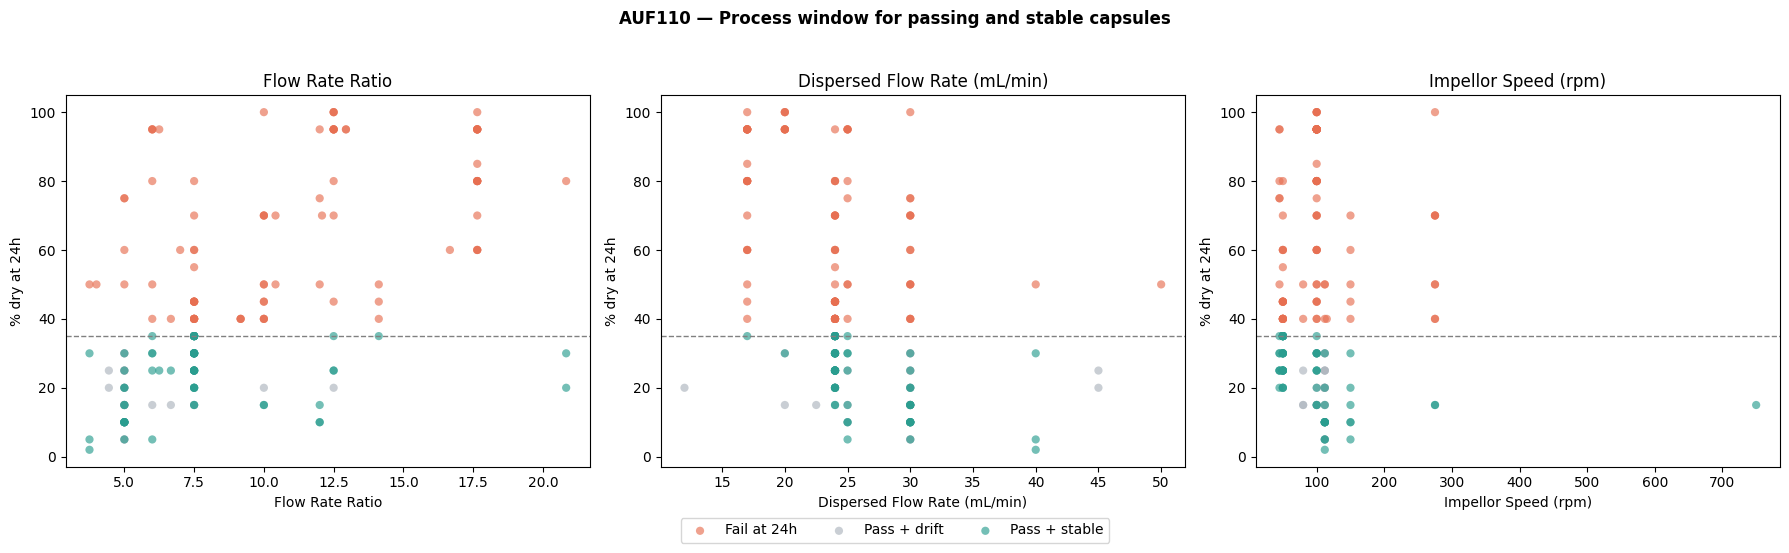

Saved auf110_process_window.png


In [ ]:
# Scatter plots to show the operating window
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colour_map = {
    'Pass + stable': '#2a9d8f',
    'Pass + drift': '#adb5bd',
    'Fail at 24h': '#e76f51'
}

for ax, col in zip(
    axes,
    ['Flow Rate Ratio', 'Dispersed Flow Rate (mL/min)', 'Impellor Speed (rpm)']
):
    for label, df_ in auf110_win.groupby('status'):
        ax.scatter(df_[col], df_[DRY_24], c=colour_map[label], label=label,
                   alpha=0.65, s=35, edgecolors='none')
    ax.axhline(35, color='grey', linestyle='--', linewidth=1)
    ax.set_xlabel(col)
    ax.set_ylabel('% dry at 24h')
    ax.set_title(col)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('AUF110 — Process window for passing and stable capsules',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('auf110_process_window.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved auf110_process_window.png")

In [ ]:
#  Median process settings for the best group
best_group = auf110_win[auf110_win['status'] == 'Pass + stable']

best_group[['Flow Rate Ratio',
            'Dispersed Flow Rate (mL/min)',
            'Impellor Speed (rpm)']].describe(percentiles=[0.25, 0.5, 0.75]).T

,count,mean,std,min,25%,50%,75%,max
Flow Rate Ratio,66.0,7.703803,3.238713,3.75,6.0,7.5,7.5,20.833333
Dispersed Flow Rate (mL/min),66.0,26.045455,4.122851,17.00,24.0,24.0,30.0,40.000000
Impellor Speed (rpm),66.0,95.590909,95.100753,45.00,50.0,50.0,112.0,750.000000


### Findings — 7c: Defining the process window

This section identifies the process settings that give AUF110 the best
chance of both **passing at 24h** and **remaining stable at 48h**.

From 177 AUF110 runs with complete data:

- **87 runs failed at 24h**
- **24 runs passed at 24h but drifted later**
- **66 runs passed and stayed stable**

This tells us something important straight away:
AUF110 is not inherently unstable. It can produce good, stable capsules,
but only when it is processed within the right window.

---

#### What the three groups look like

The runs fall into three clear groups:

**1. Fail at 24h**
These runs already have poor shell formation by 24h.
Their average settings are:

- **Flow Rate Ratio = 11.0**
- **Dispersed Flow Rate = 23.4 mL/min**
- **Impellor Speed = 104 rpm**

These settings are associated with capsules that fail immediately.

**2. Pass + drift**
These runs look good at 24h, but worsen badly by 48h.
Their average settings are:

- **Flow Rate Ratio = 5.8**
- **Dispersed Flow Rate = 28.5 mL/min**
- **Impellor Speed = 105 rpm**

So very low Flow Rate Ratio can help the shell look good at first,
but the shell does not remain stable.

**3. Pass + stable**
These are the successful runs — good at 24h and still good at 48h.
Their average settings are:

- **Flow Rate Ratio = 7.7**
- **Dispersed Flow Rate = 26.0 mL/min**
- **Impellor Speed = 95.6 rpm**

This is the key result:
the best runs sit **in the middle**, not at either extreme.

---

#### What this means

The process should not be pushed as low as possible or as high as possible.
Instead, it should be controlled inside a middle operating window.

A good first process specification for AUF110 is:

- **Flow Rate Ratio: target 6–8**
- **Dispersed Flow Rate: target 24–30 mL/min**
- **Impellor Speed: target low-to-moderate, ideally 50–112 rpm**

This is the range where AUF110 most often produced capsules that
both passed and stayed stable.

---

#### Why this window works

The earlier analysis in 7b showed two different ways capsules fail:

- **If Flow Rate Ratio is too high** and **Dispersed Flow Rate is too low**,
  the shell does not form properly and the run fails at 24h.

- **If Flow Rate Ratio is too low**, the shell can look good at 24h,
  but it becomes unstable and drifts by 48h.

So the solution is not to optimize for 24h score alone.
The process must be balanced so the capsule shell both **forms well**
and **holds over time**.

That is why the best-performing runs sit in the middle window.

---

#### Important note on outliers

A few successful runs contain extreme values, such as very high impellor speed.
These are isolated outliers and should not be treated as target settings.

The most reliable values are the central cluster of successful runs:

- Flow Rate Ratio median = **7.5**
- Dispersed Flow Rate median = **24 mL/min**
- Impellor Speed median = **50 rpm**

So the recommendation should be based on the **main successful cluster**,
not on the single highest or lowest observed values.

---

#### What about the flexible family?

This section defined the process window using AUF110 because it had the
largest number of runs and gave the clearest evidence.

However, the flexible family showed the same direction of effect in 7b:

- stable flexible runs had **lower Flow Rate Ratio**
- **higher Dispersed Flow Rate**
- and **lower Impellor Speed**
  than the high drift flexible runs

That means the AUF110 window is not just an AUF110 finding.
It appears to describe the **best processing region for the encapsulation
process itself**.

So flexible family formulations that are currently drifting or failing
are likely to benefit from being run inside the same process window.

---

#### conclusion

> AUF110 does not need a new formulation.
> It needs tighter process control.

The best performing AUF110 runs all sit inside a clear operating window.
The flexible family shows the same process pattern.
This suggests Albotherm should not only choose the best formulation family,
but also **standardize the manufacturing process** across all families.

The main recommendation is therefore:

- use **Flow Rate Ratio 6–8**
- use **Dispersed Flow Rate 24–30 mL/min**
- keep **Impellor Speed low to moderate**

This is the best supported starting specification from the current data,
and it should be used in future runs to improve consistency.

### 7d — Final Recommendation

This section brings together everything from 7a, 7b, and 7c into
one clear answer to the original question:

> *Which formulation should Albotherm use, and how should it be run?*

---

#### What the analysis found

Section 7 started by asking why AUF110 — a formulation with a fixed
recipe across 213 runs — produced such inconsistent results.

The answer was not in the formulation. It was in the process.

Three process settings — **Flow Rate Ratio, Dispersed Flow Rate,
and Impellor Speed** — explained most of the variation in both
24h performance and long-term stability. When those settings were
in range, capsules passed and stayed stable. When they were out of
range, capsules either failed immediately or passed and then drifted.

The same pattern appeared in the flexible family. The same three
parameters separated stable runs from unstable ones — regardless
of which formulation code was being run.

This means the inconsistency seen across the dataset is not primarily
a formulation problem. It is a process control problem.

---

#### Which formulation direction is right?

The flexible family — AUF076, AUF285, AUF075, AUF302, and AUF274 —
shares a common chemical trait that appears to be associated with
better stability potential than AUF110.

Within the flexible family, two formulations stand out:

**AUF285** — 74% pass rate with near zero drift at 48h.
It not only passes but stays stable. Of the formulations with
enough data to analyse, AUF285 has the best combination of
durability and stability.

**AUF302** — 100% pass rate with slightly negative drift across
8 runs. The best numbers in the dataset

# 8.  Executive Summary

This notebook analyses manufacturing runs across 35 UV formulations
produced by Albotherm. The goal was to understand why performance is
inconsistent and which formulation and process conditions give the
best results.

---

#### What was studied

Each run produces capsules that are tested for durability at 24 hours
and again at 48 hours. A passing run has less than 35% dry weight at
24h. A stable run holds that result at 48h without significant
deterioration.

The dataset captures the formulation used, the ingredients, and 15
process settings for each run.

---

#### What was found

**1. Most runs fail — and failure is not random**

Across the dataset, a large proportion of runs either fail the 24h
test outright or pass at 24h and then deteriorate significantly by
48h. This inconsistency is not caused by the formulation recipe,
which remains fixed within each formulation. It is caused by
variation in how the formulations are processed.

**2. There are two distinct failure modes**

Every failing run falls into one of two categories:

- **Fail at 24h** — the capsule shell never forms properly.
  Flow Rate Ratio is too high and Dispersed Flow Rate is too low.
  The run fails immediately and does not worsen further.

- **Pass then drift** — the capsule looks good at 24h but
  deteriorates by 48h. Flow Rate Ratio is too low.
  The shell forms well initially but is too fragile to hold.
  These are the most dangerous runs because they appear to pass
  quality checks and then fail in use.

**3. Three process settings control both failure modes**

The same three settings repeatedly separate good runs from bad ones
across all formulations tested:

- **Flow Rate Ratio** — the single most important setting.
  Must be kept between 6 and 8. Too high causes immediate failure.
  Too low causes later drift.

- **Dispersed Flow Rate** — target 24 to 30 mL/min.
  Controls how well the shell forms in the first place.

- **Impellor Speed** — keep low to moderate, ideally 50 to 112 rpm.
  Less critical than the other two, but high values are associated
  with increased instability over time.

**4. The flexible family is the right formulation direction**

The flexible family — AUF076, AUF285, AUF075, AUF302, and AUF274 —
shares a common chemistry that shows better stability potential
than AUF110. Within this family, AUF285 and AUF302 have the
strongest performance signals.

However, performance differences between flexible family members
are currently difficult to separate from process variation. Some
formulations may appear weaker simply because they were run under
poorer process settings.

**5. The process must be standardized before a final formulation
decision is made**

At present, formulations are not being compared on equal terms.
The same formulation produces very different results depending on
which process settings were used. This means the current dataset
cannot give a definitive answer on which flexible family formulation
is best — only that the flexible family chemistry is the right
direction.

---

#### What Albotherm should do

**Immediately:**
Adopt the process window defined in Section 7c as a standard
operating specification for all runs:
- Flow Rate Ratio: **6–8**
- Dispersed Flow Rate: **24–30 mL/min**
- Impellor Speed: **50–112 rpm**

**Next:**
Run a controlled trial of AUF285 and AUF302 inside recommended process settings to confirm their performance under standardized conditions.
Expand the AUF302 sample size — currently only 8 runs — before
making it a primary recommendation.

---
#### The one line conclusion

> Albotherm does not have a formulation problem.
> It has a process control problem.
> Fix the process first — then the best formulation will
> clearly reveal itself.

# Hypothesis & Modelling Direction and Optimisation

This section does not just list what to do next.
It states what we expect to find and why.

---
### 9a — What we now believe (informed hypotheses)

Before running any further experiments or models, the current
analysis supports the following positions:

**H1 — The process window is the primary driver of capsule quality**
Flow Rate Ratio, Dispersed Flow Rate, and Impellor Speed explain
most of the variation in 24h score and drift across all formulations.
We expect that standardizing these three settings will reduce
pass rate variance significantly — regardless of which flexible
family formulation is being run.

**H2 — The flexible family chemistry is fundamentally more stable**
Across comparable run conditions, flexible family formulations
show lower drift than AUF110. This suggests the chemical
composition of the flexible family produces a more robust shell
— but this advantage is currently being masked by process
variation.

**H3 — AUF285 and AUF302 are the strongest formulation candidates**
Within the flexible family, AUF285 shows the best combination of
pass rate and stability across a meaningful sample size. AUF302
shows the best absolute numbers but needs more runs to confirm.
We expect both to outperform AUF076 and AUF075 when tested under
standardized process conditions.

**H4 — AUF075's drift problem is a process problem, not a chemistry problem**
AUF075 has a 100% pass rate at 24h but drifts heavily. This is
the signature of a run operating with Flow Rate Ratio too low.
We expect AUF075 performance to stabilize significantly when
run inside the correct process window.

**H5 — A Random Forest model will confirm Flow Rate Ratio as the
single most important process variable**
The correlation analysis in 7b showed Flow Rate Ratio as the
strongest predictor of both 24h score (r = 0.57) and drift
(r = −0.40). A model based importance ranking should confirm
this and give a clearer hierarchy of all 15 parameters.

---

### 9b — Immediate next steps for Albotherm

**Step 1 — Implement the process window as standard operating procedure**

This is the highest impact, lowest cost action available right now.
No new experiments needed — just tighter control of existing settings.

Target specification:
- Flow Rate Ratio: **6–8**
- Dispersed Flow Rate: **24–30 mL/min**
- Impellor Speed: **50–112 rpm**

Expected outcome: pass rates improve and drift reduces across all
flexible family formulations within the first controlled batch.

**Step 2 — Run a head to head flexible family trial**

Test AUF076, AUF285, AUF075, and AUF302 under identical process
conditions inside the defined window.

This is the only way to answer the question:
*are these formulations genuinely different, or were they just
processed differently?*

Expected outcome: performance differences between flexible family
members narrow significantly, and AUF285 or AUF302 emerges as
the clear leader.

**Step 3 — Expand AUF302 sample size**

AUF302 has the best numbers in the dataset but only 8 runs.
Target: 30–50 runs under standardized conditions before treating
it as the primary recommendation.

Expected outcome: AUF302 either confirms its position as the
top performer or reveals that the 8 run signal was a small
sample artefact.

---



---

**optimisation**

> *Hypothesis: the true optimal Flow Rate Ratio sits between 6.5
> and 7.5, with Dispersed Flow Rate between 25 and 28 mL/min —
> tighter than the current observational window.*

The EDA gave a optimisation starting point. DOE and optimisation will confirm and sharpen it.





---
